<a href="https://colab.research.google.com/github/LuanLindolfo/machinelearning/blob/Classificacao/Classificacaoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning e Data Science com Python de A à Z (Classificacão) - IA Expert Academy

# Importação das bibliotecas básicas

In [ ]:
import os #peguei do chatgpt so pra reinicar o ambiente
os.kill(os.getpid(), 9)
!pip uninstall -y numpy
!pip install numpy==1.26.4

In [ ]:
!pip -q install plotly

In [ ]:
!pip -q install yellowbrick

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Base de dados de crédito

- Fonte (adaptado): https://www.kaggle.com/laotse/credit-risk-dataset

In [ ]:
from google.colab import drive#carregando a base de dados pro ambiente do collab
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

### Exploração dos dados

In [ ]:
base_credit = pd.read_csv('/content/credit_data.csv') #importando o arquivo credit data que foi baixado
#no material de apoio

In [ ]:
base_credit # defaulted
#chamando os registros do arquivo
#previsao a ser feita no default
#0 pagou o imprestimo e 1 nao pagou
#sao variaveis nominais, pois o id do cliente conta como nome
#income é a renda anual, variavel numerica continua
#age é variavel numerica continuo
#loan é a dívida da pessoa é variavel numerica cotinua
#default é variavel numerica discreta (só 0 ou 1)

#o intuito é basicamente pegar esses dados e faze uma previsão
#se uma pessoa com essas caracteristicas vai pagar ou nao a divida do emprestimo

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [ ]:
base_credit.head(10) #pegando os 10 primeiros registros

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


In [ ]:
base_credit.tail(8)#para os ultimos 10 registros
#tail significa rabo

,clientid,income,age,loan,default
1992,1993,30803.806165,23.250084,623.024153,0
1993,1994,54421.410155,26.821928,3273.631823,0
1994,1995,24254.700791,37.751622,2225.284643,0
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0
1999,2000,69436.579552,56.152617,7378.833599,0


In [ ]:
base_credit.describe()#retorna a contagem para cada tributo numerico
#e dados estatisticos

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [ ]:
base_credit[base_credit['income'] >= 69995.685578] #aplicando filtro no income para
#ver a pessoa que tem o salario mais alto

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [ ]:
base_credit[base_credit['loan'] <= 1.377630]#aplicando filtro no loan para
#ver a pessoa com a menor divida

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


### Visualização dos dados

In [ ]:
np.unique(base_credit['default'], return_counts=True)#contagem no registro de cada uma das classes
#np.unique(base_credit['default'] retorna os valores que tem em default
#return_counts=True) a contagem de cada um dos elementos

(array([0, 1]), array([1717,  283]))

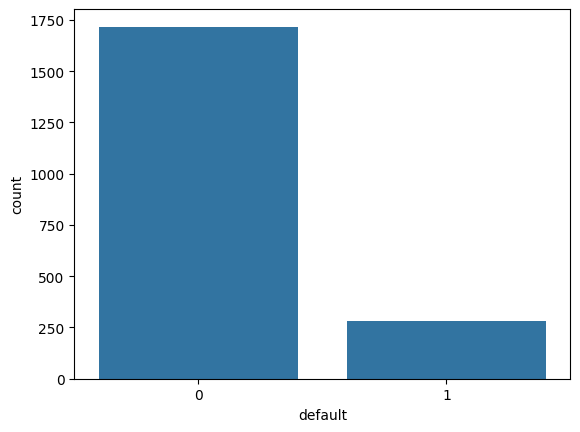

In [ ]:
sns.countplot(x = base_credit['default']);#para geracao de graficos
#(x = base_credit['default']) informando a base que quer a geracao de grafico
#base credit e o atributo default
#gerando o registro em cada uma das classes

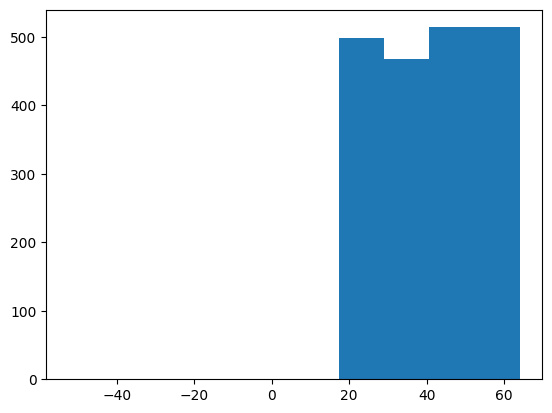

In [ ]:
plt.hist(x = base_credit['age']);#histograma
#especifico do atributo age conforme colocado no plot
#separacao dos dados em classe e intervalos

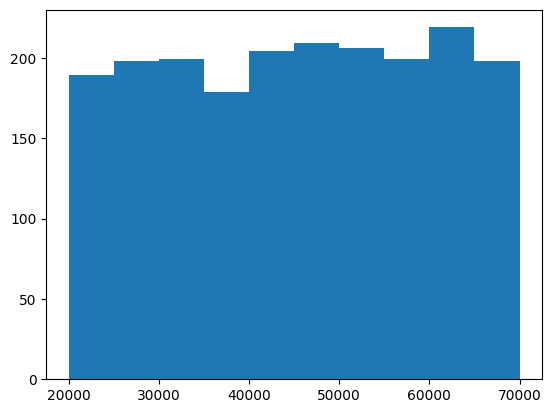

In [ ]:
plt.hist(x = base_credit['income']);#histograma do income
#sendo possivel ver a distribuicao

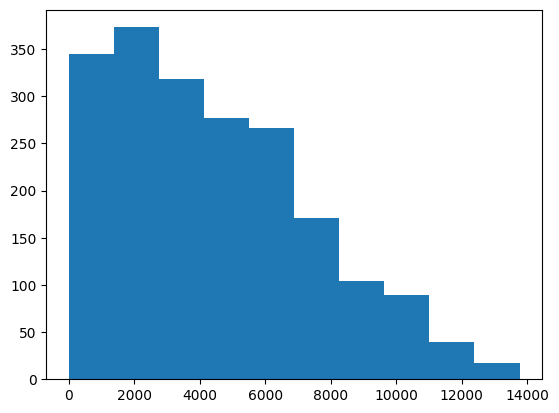

In [ ]:
plt.hist(x = base_credit['loan']);#histograma de loan

In [ ]:
grafico = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'], color = 'default')
#scatter - grafico em dispersao
#criando grafico dinamico - importante ara perceber outliers
#combina no eixo x e y
#color = 'default - cor com base nos dados de default (0 e 1), que diz se a pessoa paga ou nao paga o empréstimo
#base_credit - origem do arquivo
#juncao de atributos em graficos
#['age', 'income', 'loan'] - atributos da visualizacao nos gráficos
grafico.show()

### Tratamento de valores inconsistentes (análise em dados errados e a correção destes valores)

In [ ]:
base_credit.loc[base_credit['age'] < 0] #localizando os outliers em idade negativa
#.loc para localizacao de algum registro

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [ ]:
base_credit[base_credit['age'] < 0] #filtro direto nos dados

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [ ]:
# Apagar a coluna inteira (de todos os registros da base de dados)
#criando outra variavel para poder fazer essa manipulação
base_credit2 = base_credit.drop('age', axis = 1)
#axis - deleta, 0 = linhas e 1 = colunas. Informa o atributo (age) e a coluna
#drop() serve para remover linhas ou colunas - "quero excluir algo"
base_credit2

,clientid,income,loan,default
0,1,66155.925095,8106.532131,0
1,2,34415.153966,6564.745018,0
2,3,57317.170063,8020.953296,0
3,4,42709.534201,6103.642260,0
4,5,66952.688845,8770.099235,1
...,...,...,...,...
1995,1996,59221.044874,1926.729397,0
1996,1997,69516.127573,3503.176156,0
1997,1998,44311.449262,5522.786693,1
1998,1999,43756.056605,1622.722598,0


In [ ]:
base_credit.index #indices

RangeIndex(start=0, stop=2000, step=1)

In [ ]:
base_credit[base_credit['age'] < 0].index #retorna quais sao os indices menor que 0

Index([15, 21, 26], dtype='int64')

In [ ]:
# Apagar somente os registros com valores inconsistentes
base_credit3 = base_credit.drop(base_credit[base_credit['age'] < 0].index)
#drop() apaga os indices informados
#.index para que fale quais sao os indices a apagar
#nesse caso, os menores que 0
base_credit3

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [ ]:
base_credit3.loc[base_credit3['age'] < 0] #certificando que apagou
#informa que nao ha registro pois foram apagados corretamente

NameError: name 'base_credit3' is not defined

In [ ]:
# Preencher os valores inconsistente manualmente
# O melhor pois preenche corretamente os dados
# Mas nao e viavel em valores muito altos

In [ ]:
# Prencher a média

In [ ]:
base_credit.mean() #retorna a media

,0
clientid,1000.500000
income,45331.600018
age,40.807559
loan,4444.369695
default,0.141500


In [ ]:
base_credit['age'].mean()#retorna a media do atributo
#o problema que esta considerando os negativos

np.float64(40.80755937840458)

In [ ]:
base_credit['age'][base_credit['age'] > 0].mean()#retorna a media do atributo
#nao considera os negativos

np.float64(40.92770044906149)

In [ ]:
base_credit.loc[base_credit['age'] < 0, 'age'] = 40.92 #acessa os registros que sao menores que 0
#e os fazem receber o valor da media
#informando o atributo a ser a tualizado, se nao ele carrega em toda a linha

In [ ]:
base_credit.loc[base_credit['age'] < 0]
#checando
#nao retorna os valores negativos pois ja foram corrigidos

,clientid,income,age,loan,default


In [ ]:
base_credit.head(27)#visualizando os que estavam outliers

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


### Tratamento de valores faltantes

In [ ]:
base_credit.isnull() #mostra true ou false
#true - faltante

,clientid,income,age,loan,default
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1995,False,False,False,False,False
1996,False,False,False,False,False
1997,False,False,False,False,False
1998,False,False,False,False,False


In [ ]:
base_credit.isnull().sum()#somatorio dos true para grande valor de dados
#3 registros sem a data preenchida

,0
clientid,0
income,0
age,3
loan,0
default,0


In [ ]:
base_credit.loc[pd.isnull(base_credit['age'])]#filtro pra trazer registros que tem um valor nulo noa tributo age

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [ ]:
base_credit['age'].fillna(base_credit['age'].mean(), inplace = True)
#.fillna preencher valor nulo
#fill - preencher
#na - valor nulo
#preenchendo a media da idade
#inplace = True pra alterar o valor na base, se nao, altera so na memória

<ipython-input-69-46f86fadc184>:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
base_credit.loc[pd.isnull(base_credit['age'])]#checando
#nao ha mais nulos

,clientid,income,age,loan,default


In [ ]:
base_credit.loc[(base_credit['clientid'] == 29) | (base_credit['clientid'] == 31) | (base_credit['clientid'] == 32)]
#trazendo os ids que tinha NaN, agora preenchidos com a media

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [ ]:
base_credit.loc[base_credit['clientid'].isin([29, 31, 32])]
#forma mais rapida de localizar os ids

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


### Divisão entre previsores e classe

Divisao pois o intuito é utilizar a renda, idade e o valor da divida, pra saber se a pessoa vai pagar o emprestimo ou nao

Uma variavel para armazenar os diprevisores e outra a classe

Previsores - X e Classe - Y

In [ ]:
type(base_credit)

pandas.core.frame.DataFrame

In [ ]:
X_credit = base_credit.iloc[:, 1:4].values
#alocando os previsores, nesse caso, pegando no base_credito os atributos
#[Quantos eu quero, quais eu quero]
#: - todos
#Indo e 1 a 4, nesse caso vai de 0 a 3, mas nesse caso, faz isso pra que ele busque do 1 ao 3
#4 - uperbound -(limite superior de estatistica)
#.values para converter no final pra converter em formato do numpy para utilizar na sequencia

In [ ]:
X_credit #checando

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]])

In [ ]:
type(X_credit) #vendo o tipo
#neste caso ta em tipo numpy
#.ndarray - matriz, neste caso, da biblioteca numpy

numpy.ndarray

In [ ]:
y_credit = base_credit.iloc[:, 4].values
#alocando a o default

In [ ]:
y_credit#checando

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
type(y_credit)#vendo o tipo

numpy.ndarray

### Escalonamento dos valores

In [ ]:
X_credit #checando a variavel

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]])

In [ ]:
X_credit[:,0].min(), X_credit[:,1].min(), X_credit[:,2].min()
#vendo o minimo valor da primeira coluna (renda)
#vendo o minimo valor da segunda coluna (idade)
##vendo o minimo valor da terceira coluna (divida)

(np.float64(20014.4894700497),
 np.float64(18.055188510566897),
 np.float64(1.37762959325451))

In [ ]:
X_credit[:,0].max(), X_credit[:,1].max(), X_credit[:,2].max()
#vendo o maximo valor da primeira coluna (renda)
#vendo o maximo valor da segunda coluna (idade)
##vendo o maximo valor da terceira coluna (divida)

(np.float64(69995.6855783239),
 np.float64(63.971795841120205),
 np.float64(13766.0512393337))

In [ ]:
#padronizando os valores na mesma escala, pois o algoritmo pode entender que pela renda ser maior que a idade seria mais importante
#padronizacao (standardisation)
#x= x-media(x)/desvio padrao (x)
#normalizacao (normalization)
#x= x-minimo(x)/maximo(x)-minimo(x)
#biblioteca de py faz isso
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()
#criando objeto
X_credit = scaler_credit.fit_transform(X_credit)
#.fit_transform() se encaixa nos dados e faz a transformacao

In [ ]:
X_credit[:,0].min(), X_credit[:,1].min(), X_credit[:,2].min()#nao tem problema os negativos
#pois usa a media e desvio padrao pra chegar nesse resultado

(np.float64(-1.7676158019964077),
 np.float64(-1.726414540888992),
 np.float64(-1.459279109946241))

In [ ]:
X_credit[:,0].max(), X_credit[:,1].max(), X_credit[:,2].max()

(np.float64(1.7220222385319197),
 np.float64(1.7393673928651965),
 np.float64(3.0616609141708273))

In [ ]:
X_credit

array([[ 1.45393393,  1.36538093,  1.20281942],
       [-0.76217555,  0.5426602 ,  0.69642695],
       [ 0.83682073,  1.67417189,  1.17471147],
       ...,
       [-0.07122592, -0.97448519,  0.35420081],
       [-0.11000289,  1.73936739, -0.92675625],
       [ 1.682986  ,  1.14917639,  0.96381038]])

# Base de dados do censo

- Fonte: https://archive.ics.uci.edu/ml/datasets/adult

## Exploração dos dados

In [ ]:
base_census = pd.read_csv('/content/census.csv')
#objetivo - fazer a previsao se uma pessoa ganha mais ou menos que 50k dolares por ano
#tem mix de categoricos e numericos
#age - numerica discreta
#work class - categorica nominal
#final weight - numerica continua
#education - categorica ordinal
#education-num - numerica discreta
#as demais sao categoricas nominais
#capital gain e o loos - numerica continua
#hour-per-week - numerica discreta
#native country categorica nominal
#income - categorica ordinal

In [ ]:
base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
base_census.describe() #visualizando algumas estatisticas

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
base_census.isnull().sum() #verificando se ha valor faltante
#tudo 0, entao nao tem

,0
age,0
workclass,0
final-weight,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Visualização dos dados

In [ ]:
np.unique(base_census['income'], return_counts=True)#contagem dos registros na classe income e a quantidade pra cada

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

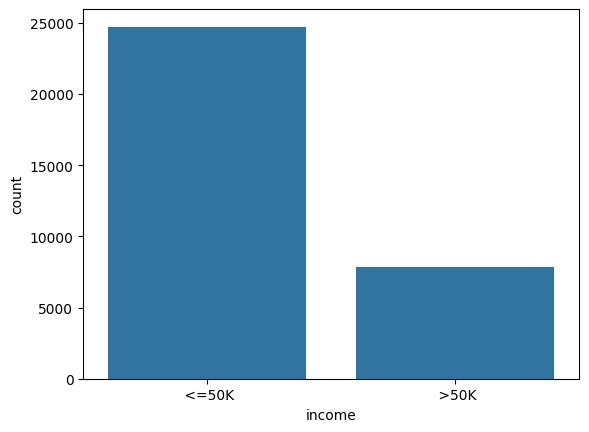

In [ ]:
sns.countplot(x = base_census['income']);#vendo o grafico

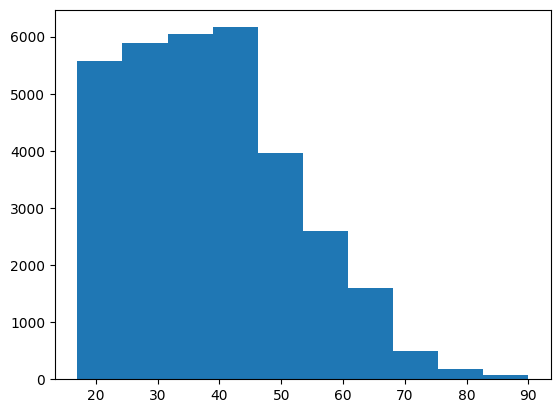

In [ ]:
plt.hist(x = base_census['age']); #histograma da idade

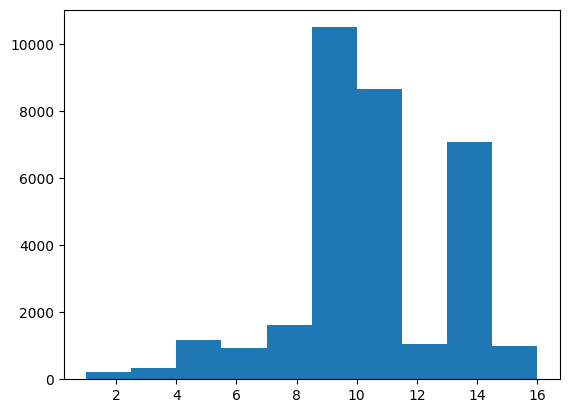

In [ ]:
plt.hist(x = base_census['education-num']);#histograma da idade dos anos que as pessoas estudas

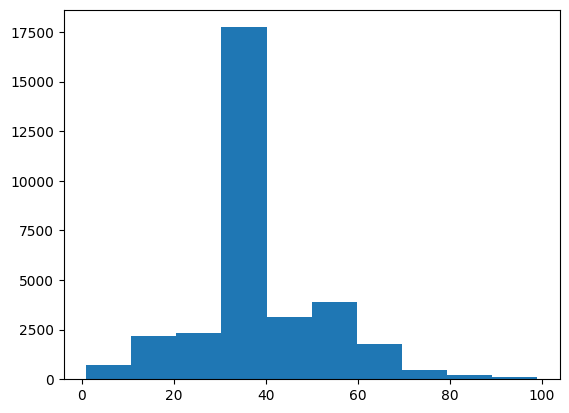

In [ ]:
plt.hist(x = base_census['hour-per-week']); #histograma das horas por semana

In [ ]:
#gerando graficos dinamicos - nesse caso usando agrupamentos
#px pimportacao para o plotly
#treemap e um tipo de grafico
#base_census como parâmetro
#path como parâmetro (as idades nas classes de trabalho)
grafico = px.treemap(base_census, path=['workclass', 'age'])
grafico.show()

In [ ]:
grafico = px.treemap(base_census, path=['occupation', 'relationship', 'age'])
#gerando graficos dinamicos - nesse caso usando agrupamentos
#px pimportacao para o plotly
#treemap e um tipo de grafico
#base_census como parâmetro
#path como parâmetro (idade, tipo de relacao e ocupacao)
grafico.show()

In [ ]:
grafico = px.parallel_categories(base_census, dimensions=['occupation', 'relationship'])
#gerando graficos dinamicos - nesse caso usando agrupamentos
#px pimportacao para o plotly
#parallel_categories e um tipo de grafico
#usando dimensoes para o grafico (ocupacao e tipo de relacao)
grafico.show()

In [ ]:
#vincunlando com o income
grafico = px.parallel_categories(base_census, dimensions=['workclass', 'occupation', 'income'])#gerando graficos dinamicos - nesse caso usando agrupamentos
#px pimportacao para o plotly
#parallel_categories e um tipo de grafico
#usando dimensoes para o grafico (ocupacao e tipo de relacao)
grafico.show()

In [ ]:
grafico = px.parallel_categories(base_census, dimensions=['education', 'income'])
#px pimportacao para o plotly
#parallel_categories e um tipo de grafico
#usando dimensoes para o grafico (educacao e income)
grafico.show()

## Divisão entre previsores e classe

Divisao pois o intuito é utilizar a renda, idade e o valor da divida, pra saber se a pessoa vai pagar o emprestimo ou nao

Uma variavel para armazenar os diprevisores e outra a classe

Previsores - X e Classe - Y

In [ ]:
base_census.columns #checando as colunas da base

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country',
       'income'],
      dtype='object')

In [ ]:
X_census = base_census.iloc[:, 0:14].values #armazenando os atributos previsores
#: - todas
# de 0 a 14
#.values - valor da biblioteca numpy
#objetivo é income

In [ ]:
X_census

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      dtype=object)

In [ ]:
X_census[0] #aqui nao entra o income

array([39, ' State-gov', 77516, ' Bachelors', 13, ' Never-married',
       ' Adm-clerical', ' Not-in-family', ' White', ' Male', 2174, 0, 40,
       ' United-States'], dtype=object)

In [ ]:
y_census = base_census.iloc[:, 14].values #armazenando os atributos classe
#: - todas
# somente a 14
#.values - valor da biblioteca numpy
#objetivo é income

In [ ]:
y_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Tratamento de atributos categóricos

### LabelEncoder

Biblioteca para conversao de dados categoricos parta numericos sendo possivel tratar os dados


In [ ]:
from sklearn.preprocessing import LabelEncoder
#Biblioteca para conversao de dados categoricos parta numericos sendo possivel tratar os dados

In [ ]:
label_encoder_teste = LabelEncoder()#objeto da classe

In [ ]:
X_census[:,1] #coluna a ser usada na biblioteca como exemplo (profissao)
#especificando as string a serem transformadas em numeros

array([' State-gov', ' Self-emp-not-inc', ' Private', ..., ' Private',
       ' Private', ' Self-emp-inc'], dtype=object)

In [ ]:
teste = label_encoder_teste.fit_transform(X_census[:,1])
#.fit_transform(X_census[:,1]) - x_census(todas as linhas, coluna 1)

In [ ]:
teste
#cada valor unico das profissoes, vao ser tranformados em numeros

array([7, 6, 4, ..., 4, 4, 5])

In [ ]:
X_census[0] #atributos

array([39, ' State-gov', 77516, ' Bachelors', 13, ' Never-married',
       ' Adm-clerical', ' Not-in-family', ' White', ' Male', 2174, 0, 40,
       ' United-States'], dtype=object)

In [ ]:
#criando um label_encoder para cada um dos atributos
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

In [ ]:
#acessando a variavel e aplicando o label_encoder para transformar
#para as colunas nao presentes, e pq ja sao numericas
X_census[:,1] = label_encoder_workclass.fit_transform(X_census[:,1])
X_census[:,3] = label_encoder_education.fit_transform(X_census[:,3])
X_census[:,5] = label_encoder_marital.fit_transform(X_census[:,5])
X_census[:,6] = label_encoder_occupation.fit_transform(X_census[:,6])
X_census[:,7] = label_encoder_relationship.fit_transform(X_census[:,7])
X_census[:,8] = label_encoder_race.fit_transform(X_census[:,8])
X_census[:,9] = label_encoder_sex.fit_transform(X_census[:,9])
X_census[:,13] = label_encoder_country.fit_transform(X_census[:,13])

In [ ]:
X_census[0] #vendo as transformacoes na posicao 0

array([39, 7, 77516, 9, 13, 4, 1, 1, 4, 1, 2174, 0, 40, 39], dtype=object)

In [ ]:
X_census #base de dados ja em atributos numericos

array([[39, 7, 77516, ..., 0, 40, 39],
       [50, 6, 83311, ..., 0, 13, 39],
       [38, 4, 215646, ..., 0, 40, 39],
       ...,
       [58, 4, 151910, ..., 0, 40, 39],
       [22, 4, 201490, ..., 0, 20, 39],
       [52, 5, 287927, ..., 0, 40, 39]], dtype=object)

### OneHotEncoder

In [ ]:
# Carro

#com o label encoder
# Gol Pálio Uno
#   1     2   3
#depois teria de normalizar os pesos das colunas

#com o OneHotEncoder
# Gol   1 0 0
# Pálio 0 1 0
# Uno   0 0 1 # encode - codificação

In [ ]:
len(np.unique(base_census['workclass'])) # 1 0 0 0 0 0 0 0 (colunas 1), 0 0 0 0 1 0 0 0 0 (coluna 5)
#contagem das categorias diferentes, logo 9 colunas

9

In [ ]:
len(np.unique(base_census['occupation']))
#contagem das categorias diferentes, logo 15 colunas

15

In [ ]:
from sklearn.preprocessing import OneHotEncoder #classes que vao fazer a transformacao
from sklearn.compose import ColumnTransformer

In [ ]:
onehotencoder_census = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [1,3,5,6,7,8,9,13])], remainder='passthrough')
#onehotencoder_census --- recebe
#ColumnTransformer -- objeto
#(transformers= -- tranformado em lista
#('OneHot'---string , OneHotEncoder() ---- implantacao, [1,3,5,6,7,8,9,13] --- lista de atributos para serem transformados
# remainder='passthrough' -- indica que nao vai apagar os outros atributos, apenas faz a transformacao nas colunas selecionadas

In [ ]:
X_census = onehotencoder_census.fit_transform(X_census).toarray()
#onehotencoder_census.fit_transform -- chama o objeto e usa o fit_transform para fazer a transformacao
#.toarray() conversao para numpy array

In [ ]:
X_census

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 2.1740e+03, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.3000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       ...,
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.5024e+04, 0.0000e+00,
        4.0000e+01]])

In [ ]:
X_census[0] #dados de apenas 1 cliente

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e

In [ ]:
X_census.shape # aumentaram de colunas pois tem o somatorio do tratamento de todos os atributos

(32561, 108)

## Escalonamento dos valores

In [ ]:
from sklearn.preprocessing import StandardScaler #para escalonamento de valores - padronizacao
scaler_census = StandardScaler() #objeto
X_census = scaler_census.fit_transform(X_census)#tranformando e escalonando

In [ ]:
X_census[0] #todos os valores na mesma escala

array([-0.2444502 , -0.17429511, -0.26209736, -0.01466381, -1.5167923 ,
       -0.18838933, -0.29093568,  4.90769968, -0.02073999, -0.17175325,
       -0.19348662, -0.11609195, -0.07201601, -0.10164955, -0.1422718 ,
       -0.12664495, -0.18406376, -0.21053433,  2.25399324, -0.11334387,
       -0.68994199, -0.23637391, -0.03960742, -0.13419553, -0.53714425,
       -0.39750806, -0.02658695, -0.92284068, -0.11403678,  1.43105786,
       -0.1802846 , -0.17735813, -0.24494366,  2.76348874, -0.01662771,
       -0.37949517, -0.37774555, -0.17745022, -0.20957797, -0.25595432,
       -0.33554133, -0.06780164, -0.38166338, -0.14260848, -0.35531609,
       -0.17127887, -0.22710355, -0.82533335,  1.70899099, -0.17624972,
       -0.42934582, -0.34403232, -0.22492681, -0.09820087, -0.18155194,
       -0.32576824, -0.09161163,  0.4130197 , -0.70307135,  0.70307135,
       -0.13502327, -0.02416321, -0.06107342, -0.0480488 , -0.04260602,
       -0.05409379, -0.04641598, -0.02933708, -0.05714946, -0.05

# Divisão das bases em treinamento e teste

In [ ]:
from sklearn.model_selection import train_test_split #importacao das bases

## Credit data

In [ ]:
X_credit_treinamento, X_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(X_credit, y_credit, test_size = 0.25, random_state = 0)
#Criando uma posicao ara treinar e uma posicao para testar
#Pegando os objetos para criar a partir da classe
#a classe pega os registros para a criacao de cada objeto
#train_test_split(X_credit, y_credit, test_size = 0.25, random_state = 0)
#X_credit, y_credit - classes
#test_size = 0.25 - Tamanho da base de dados de teste - 25%
#random_state = 0 - para ter o mesmo registro, tem sempre que colocar, caso nao coloque, vao ser randomicos

In [ ]:
X_credit_treinamento.shape
#registros para enviar para os algoritmos aprenderem
#1500 registros e 3 colunas

(1500, 3)

In [ ]:
y_credit_treinamento.shape
#registros para enviar para os algoritmos aprenderem
#1500 registros e 1 coluna

(1500,)

In [ ]:
X_credit_teste.shape, y_credit_teste.shape
#para testar o algoritmo
#X_credit_teste.shape - 25% dos dados
#_credit_teste.shape - respostas

((500, 3), (500,))

## Census

In [ ]:
X_census_treinamento, X_census_teste, y_census_treinamento, y_census_teste = train_test_split(X_census, y_census, test_size = 0.15, random_state = 0)
#Criando uma posicao ara treinar e uma posicao para testar
#Pegando os objetos para criar a partir da classe
#a classe pega os registros para a criacao de cada objeto
#train_test_split(X_census, y_census, test_size = 0.15, random_state = 0)
#X_census, y_census - classes
#test_size = 0.15 - Tamanho da base de dados de teste - 15%
#random_state = 0 - para ter o mesmo registro, tem sempre que colocar, caso nao coloque, vao ser randomicos

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape
#registros para enviar para os algoritmos aprenderem
#27676 registros e 108 colunas
#27676 registros e 1 coluna

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape
#para testar o algoritmo
#X_census_teste.shape - 15% dos dados
#y_census_teste.shape - respostas

((4885, 108), (4885,))

## Salvar as variáveis

In [ ]:
#para salvar variaveis em disco para nao ter que faze o pre processamento de novo
import pickle #pacote para salvar variaveis em disco

In [ ]:
with open('credit.pkl', mode = 'wb') as f:
  #'credit.pkl' nome do arquivo e extensao
  #mode = 'wb'para salvar a variavel
  #f - variavel para usar com o pickle para salvar em disco
  pickle.dump([X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste], f)
  #as variaveis que vao ser salvas

In [ ]:
with open('census.pkl', mode = 'wb') as f:
  #'census.pkl' nome do arquivo e extensao
    #mode = 'wb'para salvar a variavel
  #f - variavel para usar com o pickle para salvar em disco
  pickle.dump([X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste], f)
  #as variaveis que vao ser salvas

# Naïve Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
#GaussianNB - para distribuicao estatistica - problemas mais genericos
#importando a biblioteca pra utilizar o Naive Bayes
#sklearn. - para trabalhar com os algoritmos de aprendizado de maquina
#.naive_bayes pra utilizar o Naive Bayes

## Base risco de crédito

In [ ]:
base_risco_credito = pd.read_csv('/content/risco_credito.csv')

In [ ]:
base_risco_credito

,historia,divida,garantias,renda,risco
0,2,0,1,0,alto
1,1,0,1,1,alto
2,1,1,1,1,moderado
3,1,1,1,2,alto
4,1,1,1,2,baixo
5,1,1,0,2,baixo
6,2,1,1,0,alto
7,2,1,0,2,moderado
8,0,1,1,2,baixo
9,0,0,0,2,baixo


In [ ]:
X_risco_credito = base_risco_credito.iloc[:, 0:4].values
#.values para numpy array
X_risco_credito
#pre processamento
#x - previsores
#y - classes

array([['ruim', 'alta', 'nenhuma', '0_15'],
       ['desconhecida', 'alta', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'adequada', 'acima_35'],
       ['ruim', 'baixa', 'nenhuma', '0_15'],
       ['ruim', 'baixa', 'adequada', 'acima_35'],
       ['boa', 'baixa', 'nenhuma', 'acima_35'],
       ['boa', 'alta', 'adequada', 'acima_35'],
       ['boa', 'alta', 'nenhuma', '0_15'],
       ['boa', 'alta', 'nenhuma', '15_35'],
       ['boa', 'alta', 'nenhuma', 'acima_35'],
       ['ruim', 'alta', 'nenhuma', '15_35']], dtype=object)

In [ ]:
y_risco_credito = base_risco_credito.iloc[:, 4].values
#.values
y_risco_credito
#pre processamento
#x - previsores
#y - classes

array(['alto', 'alto', 'moderado', 'alto', 'baixo', 'baixo', 'alto',
       'moderado', 'baixo', 'baixo', 'alto', 'moderado', 'baixo', 'alto'],
      dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder_historia = LabelEncoder()
label_encoder_divida = LabelEncoder()
label_encoder_garantia = LabelEncoder()
label_encoder_renda = LabelEncoder()
#transformando de categorico para numerico com label encoder

In [ ]:
#aplicando processamento da transformacao
X_risco_credito[:,0] = label_encoder_historia.fit_transform(X_risco_credito[:,0])#acessando o indice (0) pra tranformacao
X_risco_credito[:,1] = label_encoder_divida.fit_transform(X_risco_credito[:,1])#acessando o indice (1) pra tranformacao
X_risco_credito[:,2] = label_encoder_garantia.fit_transform(X_risco_credito[:,2])#acessando o indice (2) pra tranformacao
X_risco_credito[:,3] = label_encoder_renda.fit_transform(X_risco_credito[:,3])#acessando o indice (3) pra tranformacao

In [ ]:
X_risco_credito #checando
#base de dados pequena, logo nao precisa do onehotencoder

array([[2, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 2],
       [1, 1, 0, 2],
       [2, 1, 1, 0],
       [2, 1, 0, 2],
       [0, 1, 1, 2],
       [0, 0, 0, 2],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 0, 1, 2],
       [2, 0, 1, 1]], dtype=object)

In [ ]:
import pickle #salvando pra nao ter que fazer o preprocessamento de novo
#salvando o pre processamento na base, nao so na memoria
with open('risco_credito.pkl', 'wb') as f:
  pickle.dump([X_risco_credito, y_risco_credito], f)

In [ ]:
#criando o algoritmo naive bayes
naive_risco_credito = GaussianNB()
#Treinamento do algoritmo
#Gerando a tabela de probabilidades
#Que seja diferentes das originais processadas
#.fit - para encaixar (o algoritmo vai se encaixar nesses dados - tabela de probabilidades)
naive_risco_credito.fit(X_risco_credito, y_risco_credito)
#(X_risco_credito, y_risco_credito)
#1 parametro - provisores
#2 parametro - classes

GaussianNB()

In [ ]:
#Associando as formas categoricas em formato numerico
# história boa (0), dívida alta (0), garantias nenhuma (1), renda > 35 (2)
# história ruim (2), dívida alta (0), garantias adequada (0), renda < 15 (0)
#Passando como parametro
previsao = naive_risco_credito.predict([[0,0,1,2], [2,0,0,0]])
#gerando uma previsao do algoritmo passando dados
# tem um cliente e nao sabe a qual classe ele pertence
#.predict - recebe os parametros de x, no caso, atributos
#O python faz a correcao laplaciana

In [ ]:
previsao #checando a previsao

array(['baixo', 'moderado'], dtype='<U8')

In [ ]:
naive_risco_credito.classes_ #vendo as classes

NameError: name 'naive_risco_credito' is not defined

In [ ]:
naive_risco_credito.class_count_ #contando os registros atributos tendo por classe

In [ ]:
naive_risco_credito.class_prior_ #probabilidades a priori

array([0.42857143, 0.35714286, 0.21428571])

## Base credit data - 93.80%

In [ ]:
import pickle
with open('/content/credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f) #criando as variaveis de teste e treinamento

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape #vendo o formato de cada uma
#x - previsores
#y - classes
#treinando com 1500 registros

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape #vendo o formato de cada uma
#dados que vai enviar pro algoritmo depois que ele estiver treinado
#x - previsores
#y - classes
#testando com 500 registros

((500, 3), (500,))

In [ ]:
naive_credit_data = GaussianNB() #algoritmo naive bayes
naive_credit_data.fit(X_credit_treinamento, y_credit_treinamento) #gerando as tabelas de probabilidade
#X_credit_treinamento - previsores
#y_credit_treinamento  - variavels que tem as saidas esperadas

GaussianNB()

In [ ]:
#enviando 500 registros de dados
previsoes = naive_credit_data.predict(X_credit_teste) #fazendo previsoes com registros que nao sei a qual classe pertence
#algoritmo ja esta treinado

In [ ]:
previsoes #resposta do algoritmo

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
y_credit_teste #comparando com as respostas reais - registro com registro

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy_score - para contagem de quantos acertos e quantos erros
#confusion_matrix - matriz de confusao

In [ ]:
accuracy_score(y_credit_teste, previsoes)
#parametros para a contagem de erros e acertos

0.938

In [ ]:
confusion_matrix(y_credit_teste, previsoes)
#matriz que indica os acertos classe por classe
#Linha 1 - que pagam ([428,   8])
#428 - clientes que pagam e pagam
#8 - clientes que pagam e foram classificados errados
#Linha 2 - nao pagam
#41 - clientes que nao pagam e foram classificados como nao pagam
#23 - clientes que nao pagam e foram classificados com que pagam

array([[428,   8],
       [ 23,  41]])

In [ ]:
from yellowbrick.classifier import ConfusionMatrix #para ver mais facilitada a matriz

0.938

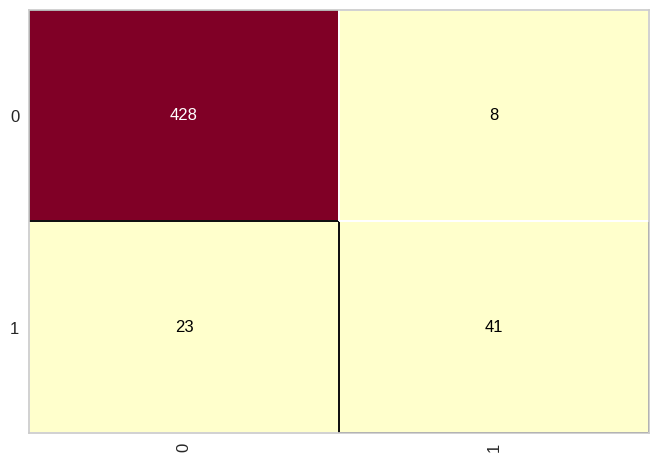

In [ ]:
#instanciando o objeto com os parametros para ver a matriz
cm = ConfusionMatrix(naive_credit_data)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)
#intersecoes que dao erro - 0 com 1 e 1 com 0, esses sao os erros

In [ ]:
print(classification_report(y_credit_teste, previsoes))#avaliando uma ultima métrica
#classification_report classificacao que vai mostrar umas metricas
#analise de precisao

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       436
           1       0.84      0.64      0.73        64

    accuracy                           0.94       500
   macro avg       0.89      0.81      0.85       500
weighted avg       0.93      0.94      0.93       500



## Base census - 47.67%

In [ ]:
with open('/content/census.pkl', 'rb') as f: #abrindo o arquivo
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape #checando os previsores e a resposta do treinamento
#grande pq usou o onehotcoder

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape #checando os previsores e a resposta do treinamento
#grande pq usou o onehotcoder

((4885, 108), (4885,))

In [ ]:
#usando o algoritmo Naive Bayes
naive_census = GaussianNB()
#treinamento e dados - previsores, classe
naive_census.fit(X_census_treinamento, y_census_treinamento)
#teste e dados - previsores, classe
previsoes = naive_census.predict(X_census_teste)
previsoes

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [ ]:
y_census_teste #comparando com as respostas reais

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
accuracy_score(y_census_teste, previsoes) # não executar o escalonamento - vai ter um algoritmo mais proximo
#neste caso, ta mantendo pra recebe rum valor muito melhor com os outros algoritmos
#taxa de acerto

0.4767656090071648

0.4767656090071648

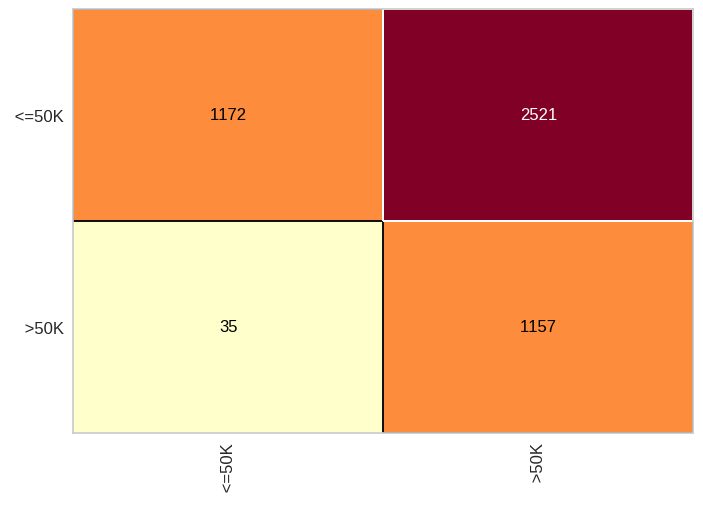

In [ ]:
#matriz de confusao
cm = ConfusionMatrix(naive_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)

In [ ]:
print(classification_report(y_census_teste, previsoes))
#analise de precisao

              precision    recall  f1-score   support

       <=50K       0.97      0.32      0.48      3693
        >50K       0.31      0.97      0.48      1192

    accuracy                           0.48      4885
   macro avg       0.64      0.64      0.48      4885
weighted avg       0.81      0.48      0.48      4885



# Árvores de decisão

In [ ]:
#importação para algoritmo
from sklearn.tree import DecisionTreeClassifier
#DecisionTreeClassifier - Classificador por árvores de decisão

## Base risco de crédito

In [ ]:
import pickle
with open('risco_credito.pkl', 'rb') as f:
  #x - previsores
  #y - classes
  X_risco_credito, y_risco_credito = pickle.load(f)
  #ja com aplicacao do labelenvoder
  #credito, divida, garantia e renda

In [ ]:
X_risco_credito

array([[2, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 2],
       [1, 1, 0, 2],
       [2, 1, 1, 0],
       [2, 1, 0, 2],
       [0, 1, 1, 2],
       [0, 0, 0, 2],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 0, 1, 2],
       [2, 0, 1, 1]], dtype=object)

In [ ]:
y_risco_credito

array(['alto', 'alto', 'moderado', 'alto', 'baixo', 'baixo', 'alto',
       'moderado', 'baixo', 'baixo', 'alto', 'moderado', 'baixo', 'alto'],
      dtype=object)

In [ ]:
#Criando árvore de decisão
arvore_risco_credito = DecisionTreeClassifier(criterion='entropy')
#DecisionTreeClassifier objeto que foi importado
#critério - criterion='entropy'
arvore_risco_credito.fit(X_risco_credito, y_risco_credito)
#.fit - encaixar os dados no algoritmo
#gerando todos os calculos
#(X_risco_credito, y_risco_credito) - parametros

DecisionTreeClassifier(criterion='entropy')

In [ ]:
arvore_risco_credito.feature_importances_
#.feature_importances_ - retorna a importancia de cada um dos atributos
#ou seja, o que tem o maior ganho d einformação

array([0.48015651, 0.06408636, 0.03885431, 0.41690281])

In [ ]:
arvore_risco_credito.classes_
#lista de valores das classes

array(['alto', 'baixo', 'moderado'], dtype=object)

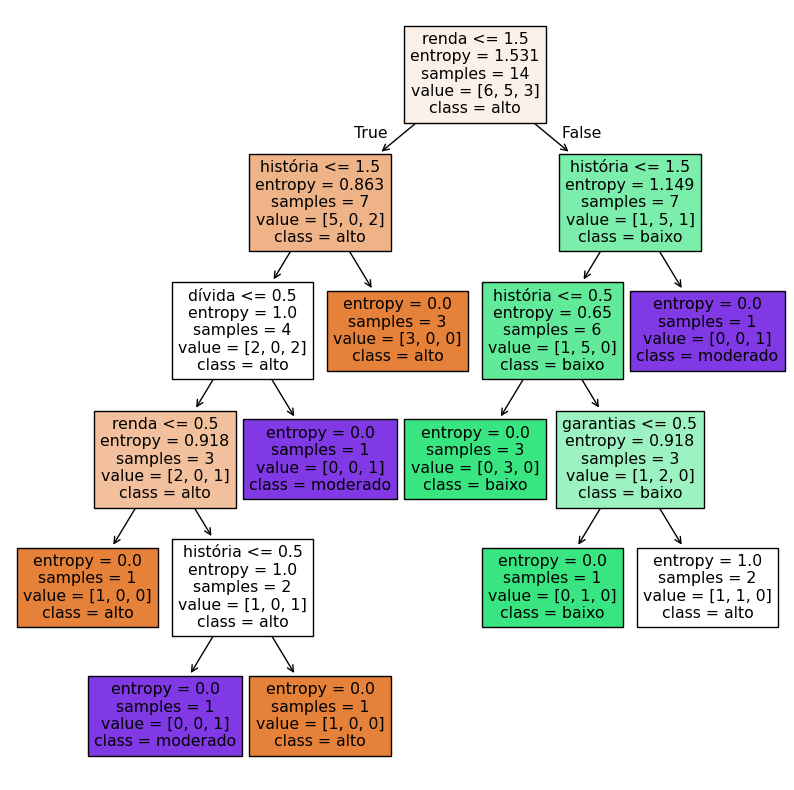

In [ ]:
from sklearn import tree
#gerando o grafico da arvore de decisao
previsores = ['história', 'dívida', 'garantias', 'renda']
#para melhor visualizacao, atributos em lista
figura, eixos = plt.subplots(nrows=1, ncols=1, figsize=(10,10))
#definindo uma figura
tree.plot_tree(arvore_risco_credito, feature_names=previsores, class_names = arvore_risco_credito.classes_, filled=True);
#filled=True - preenchendo o grafico para melhor visualizacao
#importanto tudo no metodo da arvore
#class_names = arvore_risco_credito.classes_ - pra falar se o risco é alto, moderado ou baixo

In [ ]:
# história boa, dívida alta, garantias nenhuma, renda > 35
# história ruim, dívida alta, garantias adequada, renda < 15
previsoes = arvore_risco_credito.predict([[0,0,1,2],[2,0,0,0]])
#fazendo previsao com clientes com essas caracteristicas - [[0,0,1,2],[2,0,0,0]]
#botando as previsoes em formato de matriz
previsoes

array(['baixo', 'alto'], dtype=object)

## Base credit data - 98.20%

In [ ]:
with open('credit.pkl', 'rb') as f: #abrindo o arquivo
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)#variaveis
  #income, renda, divida e a idade

FileNotFoundError: [Errno 2] No such file or directory: 'credit.pkl'

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape #vendo o tamanho

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape#vendo o tamanho do teste

((500, 3), (500,))

In [ ]:
arvore_credit = DecisionTreeClassifier(criterion='entropy', random_state = 0)
#criando a arvore de decisao
arvore_credit.fit(X_credit_treinamento, y_credit_treinamento)
#passando os parametros e encaixando as varaveis

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
previsoes = arvore_credit.predict(X_credit_teste) #respostas de teste
previsoes #resposta que pagou e nao pagou

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
y_credit_teste #resposta reais
#comparativo

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
#para gerar as metricas

In [ ]:
accuracy_score(y_credit_teste, previsoes) #taxa de acerto

0.982

0.982

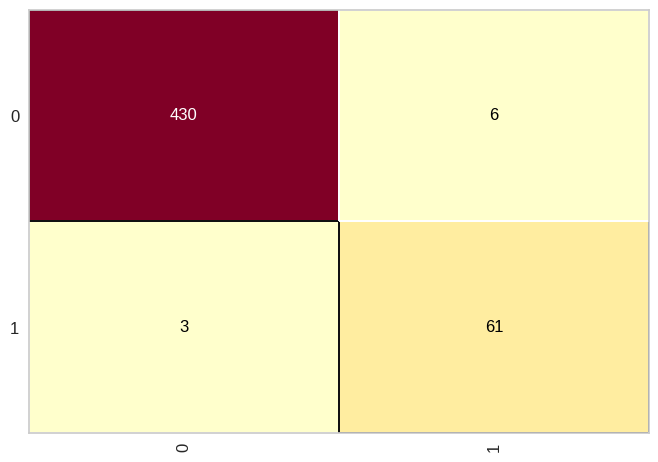

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusao
#Ela mostra a comparação entre os valores reais e os valores previstos pelo modelo.
cm = ConfusionMatrix(arvore_credit)
#passando os dados
cm.fit(X_credit_treinamento, y_credit_treinamento)
#encaixando atributos
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
print(classification_report(y_credit_teste, previsoes))#metricas

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       436
           1       0.91      0.95      0.93        64

    accuracy                           0.98       500
   macro avg       0.95      0.97      0.96       500
weighted avg       0.98      0.98      0.98       500



In [ ]:
arvore_credit.classes_

array([0, 1])

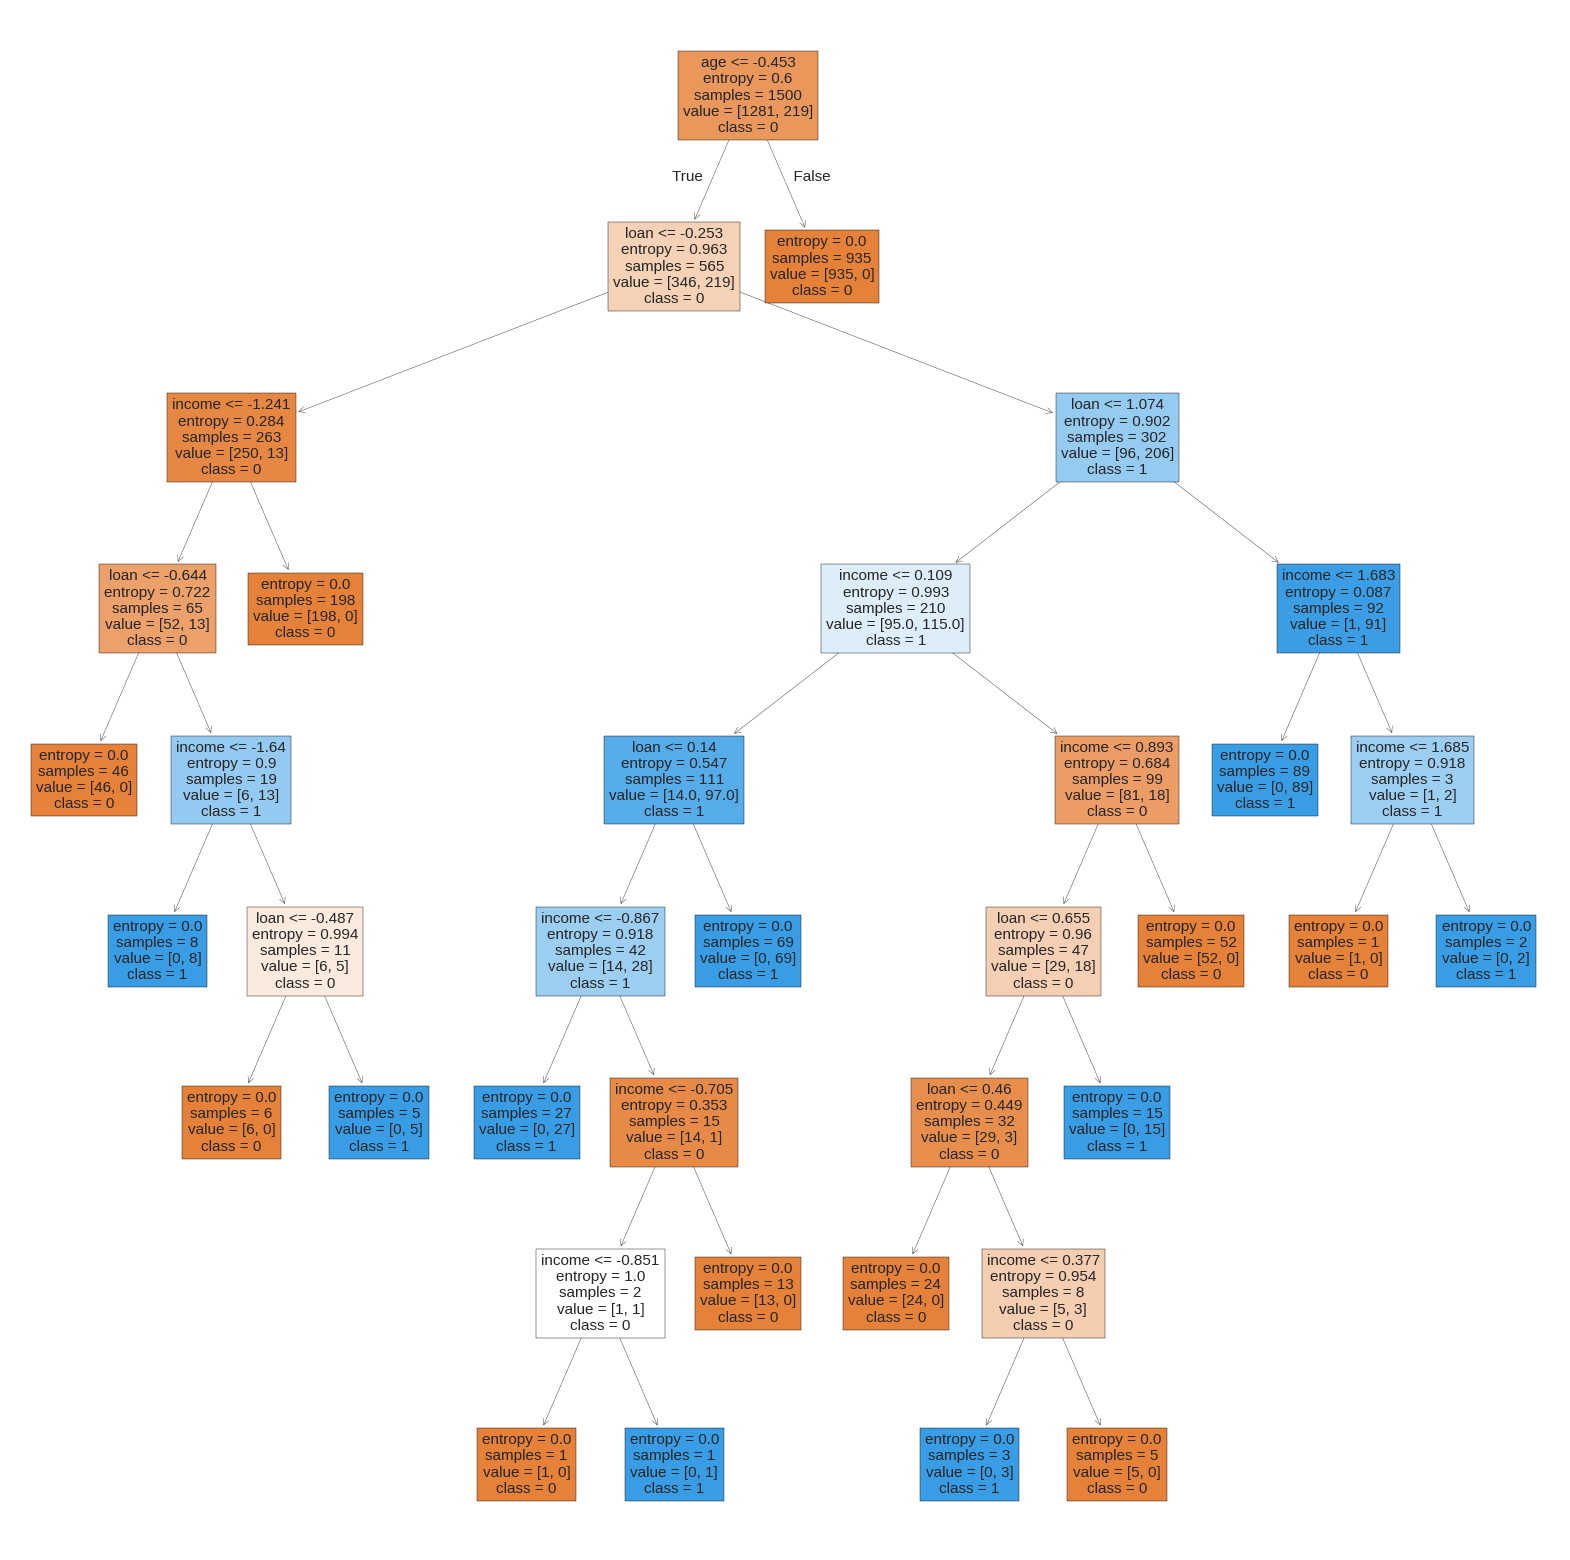

In [ ]:
from sklearn import tree
#importando a biblioteca para a arvore
previsores = ['income', 'age', 'loan']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (20,20))
#subplots(nrows = 1,ncols = 1,figsize = (20,20))- subgrafico com 1 linha e 1 coluna no tamanho 20x20
tree.plot_tree(arvore_credit, feature_names=previsores, class_names=['0','1'], filled=True);
#passando os atributos para arvore
fig.savefig('arvore_credit.png')
#salvando a imagem

## Base census - 81.04%

In [ ]:
with open('census.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape
#registros, coluna

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape
#registros para teste

((4885, 108), (4885,))

In [ ]:
arvore_census = DecisionTreeClassifier(criterion='entropy', random_state=0)
#random_state=0 - pra sempre ter os mesmo resultados
#criando a árvore com o critério de entropia
arvore_census.fit(X_census_treinamento, y_census_treinamento)
#para fazer o treinamento

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
previsoes = arvore_census.predict(X_census_teste)
previsoes
#alocando os registros de previsao na arvore

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
y_census_teste
#para fazer o comparativo

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
accuracy_score(y_census_teste, previsoes)#metrica de acerto

0.8104401228249745

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusao

0.8104401228249745

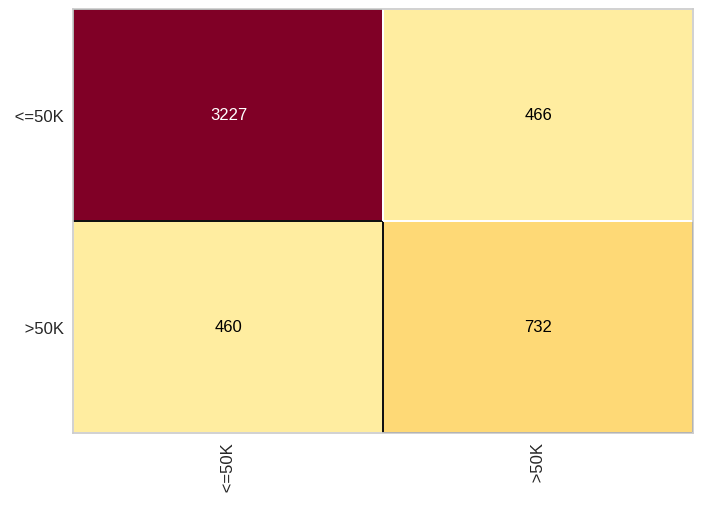

In [ ]:
#cm = ConfusionMatrix(arvore_credit) corrigido 10/04/2021
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(arvore_census)
#instanciando a matriz
cm.fit(X_census_treinamento, y_census_treinamento)
#encaixando os atributos
cm.score(X_census_teste, y_census_teste)
#fazendo os parametros da matriz
#linha - o que ele classificou
#coluna - o que realmente é

In [ ]:
print(classification_report(y_census_teste, previsoes))#metricas

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885



# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
#.ensemble - unir varios algoritmos em um so pacote

## Base credit data - 98.40%

In [ ]:
import pickle #carregando o arquivo
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape #quantidade de registros

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape #registros de avaliação

((500, 3), (500,))

In [ ]:
random_forest_credit = RandomForestClassifier(n_estimators=40, criterion='entropy', random_state = 0)
#n_estimators=40 - numero de arvores de decisao que vai criar - voto da maioria
#100 é o padrão
#Nem sempre a maior quantidade de ávores significa parametros melhores
random_forest_credit.fit(X_credit_treinamento, y_credit_treinamento)
#passando os atrributos como parametros

RandomForestClassifier(criterion='entropy', n_estimators=40, random_state=0)

In [ ]:
previsoes = random_forest_credit.predict(X_credit_teste) #gerando as previsoes
previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
y_credit_teste #valores da base de dados

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
#passando as respoista reais e as previsoes para a metrica
accuracy_score(y_credit_teste, previsoes)

0.984

0.984

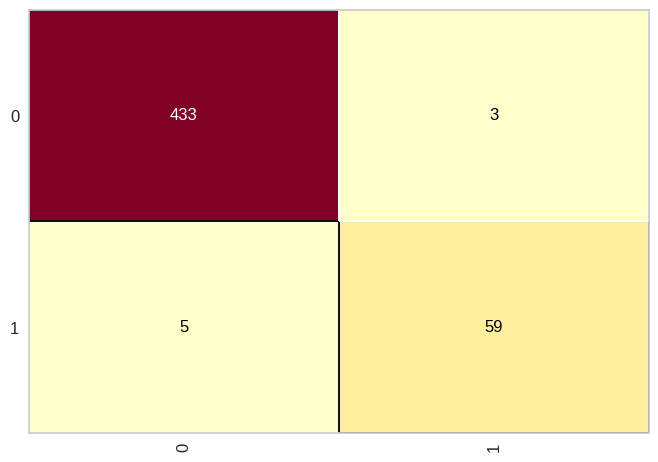

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusao
cm = ConfusionMatrix(random_forest_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)
#encaixando os atributos como parametro e verificando as metricas

In [ ]:
print(classification_report(y_credit_teste, previsoes))
#recall 0,99 - identifica 99% dos elementos com confiabilidade de 99% (precision) na classe 0
#recall 0,92 - identifica 92% dos elementos com confiabilidade de 95% (precision) na classe 1

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       436
           1       0.95      0.92      0.94        64

    accuracy                           0.98       500
   macro avg       0.97      0.96      0.96       500
weighted avg       0.98      0.98      0.98       500



## Base census - 85.07%

In [ ]:
with open('census.pkl', 'rb') as f:#upando arquivos
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape#registros de treinamento

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape#registro de teste - avaliação do algoritmo

((4885, 108), (4885,))

In [ ]:
y_census_treinamento #classes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' >50K', ' <=50K'],
      dtype=object)

In [ ]:
random_forest_census = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state = 0)
#criando as árvores
random_forest_census.fit(X_census_treinamento, y_census_treinamento)
#encaixando atributos (previsores, classe)

RandomForestClassifier(criterion='entropy', random_state=0)

In [ ]:
previsoes = random_forest_census.predict(X_census_teste) #variavel que recebe a fucnionalidade
#só com os dados de teste
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
y_census_teste#respostas reais
#para comparacao com as respostas reais

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
#importando as funcionalidade com as metricas
accuracy_score(y_census_teste, previsoes)

0.8507676560900717

0.8507676560900717

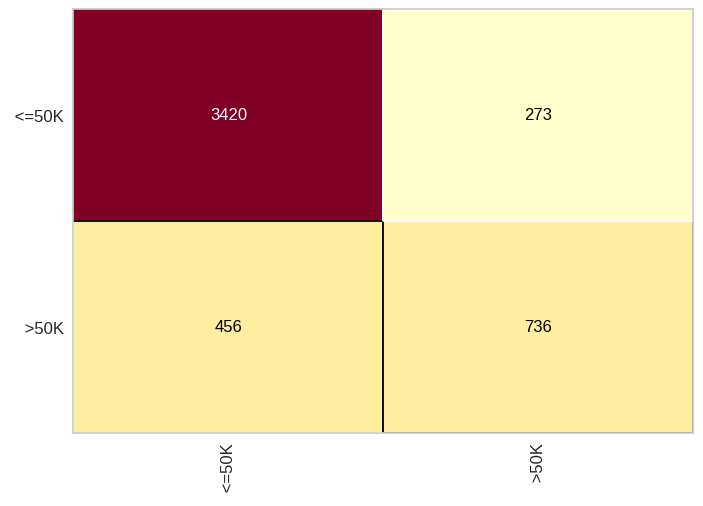

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusao
cm = ConfusionMatrix(random_forest_census)
cm.fit(X_census_treinamento, y_census_treinamento)
#encaixe de aributos
cm.score(X_census_teste, y_census_teste)
#metricas

In [ ]:
print(classification_report(y_census_teste, previsoes)) #analisando os dados das metricas
#recall 0,93 - identifica 93% dos elementos com confiabilidade de 88% (precision) na classe <=50K
#recall 0,62 - identifica 62% dos elementos com confiabilidade de 73% (precision) na classe >50K

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.62      0.67      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.79      4885
weighted avg       0.85      0.85      0.85      4885



# Regras

In [ ]:
!pip install Orange3  #instalando a biblioteca
#nao precisa do pickle
#para usar API

In [ ]:
import Orange #importando a biblioteca

## Base risco de crédito

In [ ]:
base_risco_credito = Orange.data.Table('risco_credito_regras.csv') #carregando a base de dados com só 14 registros
#ao abrir o arquivo, aparece c#risco, nesse caso, é pq tem que clasificar o risco como classe

In [ ]:
base_risco_credito #checando
#| com a clsse ao lado, pra definir o que é classe

[[ruim, alta, nenhuma, 0_15 | alto],
 [desconhecida, alta, nenhuma, 15_35 | alto],
 [desconhecida, baixa, nenhuma, 15_35 | moderado],
 [desconhecida, baixa, nenhuma, acima_35 | alto],
 [desconhecida, baixa, nenhuma, acima_35 | baixo],
 ...
]

In [ ]:
base_risco_credito.domain #vendo o dominio
#previsores | classe

[historia, divida, garantias, renda | risco]

In [ ]:
cn2 = Orange.classification.rules.CN2Learner() #versao cn2 de algoritmo de associação, bem antigo
# Orange.classification.rules. - acessando o orange, pacote classification e regras
regras_risco_credito = cn2(base_risco_credito)
#passando os parâmetros - no caso, a base de dados

In [ ]:
for regras in regras_risco_credito.rule_list:
  #.rule_list - para fazer a listagem das regras
  print(regras)

IF renda==0_15 THEN risco=alto 
IF historia==boa AND divida!=alta THEN risco=baixo 
IF historia==boa AND garantias!=nenhuma THEN risco=baixo 
IF historia==boa AND renda!=15_35 THEN risco=baixo 
IF historia==boa THEN risco=moderado 
IF divida==alta THEN risco=alto 
IF historia!=desconhecida THEN risco=moderado 
IF garantias==adequada THEN risco=baixo 
IF renda==15_35 THEN risco=moderado 
IF historia==desconhecida THEN risco=baixo 
IF TRUE THEN risco=alto 


In [ ]:
#simulando uma classificação
# história boa, dívida alta, garantias nenhuma, renda > 35
# história ruim, dívida alta, garantias adequada, renda < 15
#nao precisa transformar em atributos numericos (label encoder) pois o algoritmo trabalha com atributos categóricos
previsoes = regras_risco_credito([['boa', 'alta', 'nenhuma', 'acima_35'], ['ruim', 'alta', 'adequada', '0_15']]) #passando os registros
previsoes
#o primeiro registro pertence a classe 1 o segundo a classe 0

array([1, 0])

In [ ]:
base_risco_credito.domain.class_var.values
#.domain - vendo o domínio
#.class_var - mostrar os valores da classe
#.values mostrando a lista com os valores

('alto', 'baixo', 'moderado')

In [ ]:
for i in previsoes:#vai passando de regra em regra ate conseguir executar tudo
  #print(i) - printando a quantidade de registros
  print(base_risco_credito.domain.class_var.values[i]) #printando o dominio, os valores de classe e a lista de valores

baixo
alto


## Base credit data - 97.40%

In [ ]:
base_credit = Orange.data.Table('/content/credit_data_regras.csv')
#importando o arquivo
# o id está com i#(i charp) pois vai ser ignorado esse atributo
# o c# em default para indicar que é a classe

In [ ]:
base_credit.domain
#dominios dos dados - fez a separacao correta dos atributos
#default é o objetivo

[income, age, loan | default]

In [ ]:
base_dividida = Orange.evaluation.testing.sample(base_credit, n = 0.25)
#base_credit, n = 0.25 - valor da base dados de teste, 0.25 é 25% - teste
#75% pra treinar

In [ ]:
base_dividida

([[25554.7, 42.7969, 4229.91 | 0],
  [50447.7, 58.0985, 2443.77 | 0],
  [55730.6, 55.1564, 9286.36 | 0],
  [46082.1, 55.1585, 2921.24 | 0],
  [50117.9, 32.8273, 3599.07 | 0],
  ...
 ],
 [[25146.6, 21.0542, 2890.65 | 0],
  [30961.2, 32.1143, 162.796 | 0],
  [69516.1, 23.1621, 3503.18 | 0],
  [65330.2, 28.59, 4030.8 | 0],
  [40614.7, 20.9327, 2649.7 | 0],
  ...
 ])

In [ ]:
base_dividida[0]#posicao 1

[[25554.7, 42.7969, 4229.91 | 0],
 [50447.7, 58.0985, 2443.77 | 0],
 [55730.6, 55.1564, 9286.36 | 0],
 [46082.1, 55.1585, 2921.24 | 0],
 [50117.9, 32.8273, 3599.07 | 0],
 ...
]

In [ ]:
base_dividida[1]#posicao 0

[[25146.6, 21.0542, 2890.65 | 0],
 [30961.2, 32.1143, 162.796 | 0],
 [69516.1, 23.1621, 3503.18 | 0],
 [65330.2, 28.59, 4030.8 | 0],
 [40614.7, 20.9327, 2649.7 | 0],
 ...
]

In [ ]:
base_treinamento = base_dividida[1]#base de dados de treinamento da posicao 1 - 1500 registros
base_teste = base_dividida[0]#base de dados de teste - na posicao 0

In [ ]:
len(base_treinamento), len(base_teste)#checando o tamanho

(1500, 500)

In [ ]:
cn2 = Orange.classification.rules.CN2Learner()
#cn2 e classificacao de regras
regras_credit = cn2(base_treinamento)
#instanciando com a base de dados do treinamento como parametro

In [ ]:
for regras in regras_credit.rule_list:
  print(regras)#printando o conjunto de regras

IF age>=34.9257164876908 THEN default=0 
IF loan<=2495.13299137587 AND income>=20145.9885970689 THEN default=0 
IF age<=18.055874488782102 AND income>=32197.6207010448 THEN default=0 
IF loan>=7745.75480897024 THEN default=1 
IF income>=58132.4712652713 THEN default=0 
IF loan>=5836.56338145928 AND loan>=6342.56790924236 THEN default=1 
IF income>=50360.6787929311 THEN default=0 
IF loan>=5836.56338145928 THEN default=1 
IF income>=34145.7995516248 AND income>=45971.133494749694 THEN default=0 
IF income<=32256.8615246564 AND loan>=3343.81635769923 THEN default=1 
IF loan>=5416.3577980789005 THEN default=1 
IF income>=38129.754869733 THEN default=0 
IF age>=34.1016539284028 THEN default=0 
IF loan>=4625.19337762744 THEN default=1 
IF income>=26617.0303151011 AND income>=34145.7995516248 THEN default=0 
IF loan>=4285.38691174949 THEN default=1 
IF income>=26617.0303151011 THEN default=0 
IF age>=22.656479598488698 THEN default=1 
IF income>=22089.8374845274 THEN default=0 
IF income<=21

In [ ]:
previsoes = Orange.evaluation.testing.TestOnTestData(base_treinamento, base_teste, [lambda testdata: regras_credit])
#previsoes da base de dados de teste

In [ ]:
previsoes #classe nesse formato .Results

In [ ]:
Orange.evaluation.CA(previsoes)#visualizando o acuracy
#CA - classification acuracy

array([0.994])

## Base census - 78.90% (executado na interface gráfica do Orange)

# Classificador base - Majority learner

## Base credit data - 85.85%

In [ ]:
base_credit = Orange.data.Table('/content/credit_data_regras.csv')
##marjority learner - faz a classificação dos registros com base na
#maioria dos dados da base de dados

In [ ]:
base_credit.domain #vendo os dominios
#ignora o id e default é a classe

[income, age, loan | default]

In [ ]:
majority = Orange.classification.MajorityLearner()

In [ ]:
previsoes = Orange.evaluation.testing.TestOnTestData(base_credit, base_credit, [majority])
#.TestOnTestData(base_credit, base_credit - treinando e testando na mesma base de dados
#[majority] - algoritmo do objeto acima

In [ ]:
Orange.evaluation.CA(previsoes)
#classification acuracy - .CA

array([0.8585])

In [ ]:
for registro in base_credit:
  print(registro.get_class())
  #como ta usando a mesmabase de dados para parâmetro, significa que ta classificando cada um dos registros
  #ou seja, classificando cada um dos previsores com a classe
  #valor de cada classe

0
0
0
0
1
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
1
0
0
0
1
1
0
0
0
0
0
0
0
0
0
0
0
1
1
1
0
0
0
0
0
0
0
0
0
0
0
1
1
0
0
0
1
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
1
0
1
1
0
1
0
0
1
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
1
0
1
0
0
0
0
0
0
0
0
0
0
1
0
1
1
0
0
0
1
1
0
0
0
0
1
0
0
0
0
1
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
1
1
0
0
0
1
0
1
0
0
0
0
0
0
0
0
1
0
0
0
1
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
1
0
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
1
0
0
0
1
0
0
0
1
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
1
0
0
1
0
0
0
0
0
0
1
0
0
1
0
0
0
0
0
1
0
0
0
0
0
1
0
1
0
0
0
1
0
1
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
0
1
1
0
0
0
0
0
1
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
1
0
1
0
0
0
0
0
1
0
0
0
1
0
0
1
0
0
0
0


In [ ]:
from collections import Counter
#Counter - para fazer uma contagem
Counter(str(registro.get_class()) for registro in base_credit)
#(str - convertendo para string
#1717 registros da classe 0
#283 registros da classe 1

Counter({'0': 1717, '1': 283})

In [ ]:
1717 / 2000 #dividindo o valor a maioria
#ou seja, cada registro novo é classificado como 0 pois são a maioria na base de dados

0.8585

## Base census - 75.91%

In [ ]:
base_census = Orange.data.Table('/content/census_regras.csv')

In [ ]:
base_census.domain#dominios

[age, workclass, final-weight, education, education-num, marital-status, occupation, relationship, race, sex, capital-gain, capital-loos, hour-per-week, native-country | income]

In [ ]:
majority = Orange.classification.MajorityLearner()
previsoes = Orange.evaluation.testing.TestOnTestData(base_census, base_census, [majority])
#se tiver base de dados maior, nao vale a penas fazer por aqui
#esse é bom pq tem só duas base de dados
Orange.evaluation.CA(previsoes)
#criando em formato majority

array([0.75919044])

In [ ]:
Counter(str(registro.get_class()) for registro in base_census)
#contando cada registro de regra

Counter({'<=50K': 24720, '>50K': 7841})

In [ ]:
24720 / (24720 + 7841) #maioria pelo geral

0.7591904425539756

# Aprendizagem baseada em instâncias - knn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

## Base credit data - 98.60%

In [ ]:
import pickle
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)
  #carregando variáveis

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape#treinamento, nao necessario pos kNN nao gera modelo

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape#teste

((500, 3), (500,))

In [ ]:
knn_credit = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p = 2)
#KNeighborsClassifier - classificação kNN
#n_neighbors=5 - parametro de numero de vizinhos, definindo o valor default - 5
#metric='minkowski' - maneira que o cálculo da distancia será feito
#p = 2 - inteiro - parametro de força, p = 2 para utilizar a distancia euclidiana
#metric='minkowski', p = 2 - nao precisam ser passados pois sao padroes pra se trabalhar com a distancia euclidiana
knn_credit.fit(X_credit_treinamento, y_credit_treinamento)
#encaixando e armazenando os dados

KNeighborsClassifier()

In [ ]:
previsoes = knn_credit.predict(X_credit_teste)#fazendo as previsoes
previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
y_credit_teste #comparando com o teste

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
#accuracy
accuracy_score(y_credit_teste, previsoes) #padronização
#respostas reais e previsoes sendo passadas

0.986

0.986

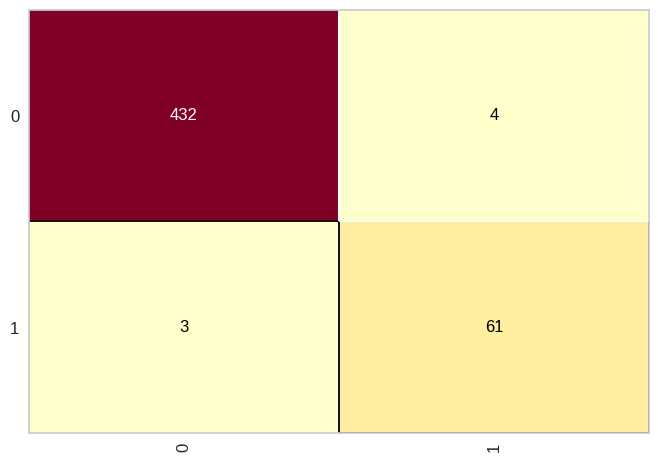

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusão
cm = ConfusionMatrix(knn_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
print(classification_report(y_credit_teste, previsoes))#metricas

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       436
           1       0.94      0.95      0.95        64

    accuracy                           0.99       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.99      0.99      0.99       500



## Base census - 82.90%

In [ ]:
with open('census.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

In [ ]:
knn_census = KNeighborsClassifier(n_neighbors=10)
#metric='minkowski', p = 2 - nao precisam ser passados pois sao
#padroes pra se trabalhar com a distancia euclidiana
knn_census.fit(X_census_treinamento, y_census_treinamento)
#rapido pra carregar mesmo com a grande quantidade de registros pois ele está armazenando dados na memória

KNeighborsClassifier(n_neighbors=10)

In [ ]:
previsoes = knn_census.predict(X_census_teste)
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_census_teste, previsoes)

0.8290685772773797

0.8290685772773797

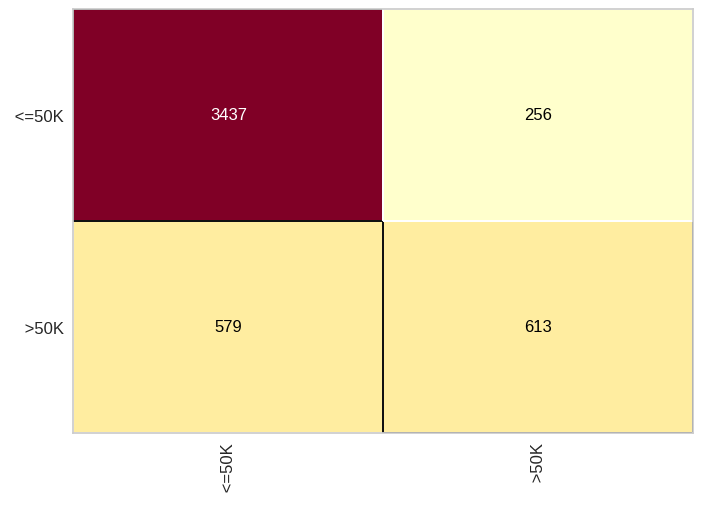

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusão
cm = ConfusionMatrix(knn_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)

In [ ]:
print(classification_report(y_census_teste, previsoes))#metricas

              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      3693
        >50K       0.71      0.51      0.59      1192

    accuracy                           0.83      4885
   macro avg       0.78      0.72      0.74      4885
weighted avg       0.82      0.83      0.82      4885



# Regressão logística

In [ ]:
from sklearn.linear_model import LogisticRegression

## Base risco de crédito

In [ ]:
import pickle
with open('risco_credito.pkl', 'rb') as f:
  X_risco_credito, y_risco_credito = pickle.load(f)

In [ ]:
X_risco_credito #historico, divida, garantia e renda

array([[2, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 2],
       [1, 1, 0, 2],
       [2, 1, 1, 0],
       [2, 1, 0, 2],
       [0, 1, 1, 2],
       [0, 0, 0, 2],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 0, 1, 2],
       [2, 0, 1, 1]], dtype=object)

In [ ]:
y_risco_credito # 2, 7, 11
#utilizando só alto e baixo

array(['alto', 'alto', 'moderado', 'alto', 'baixo', 'baixo', 'alto',
       'moderado', 'baixo', 'baixo', 'alto', 'moderado', 'baixo', 'alto'],
      dtype=object)

In [ ]:
X_risco_credito = np.delete(X_risco_credito, [2, 7, 11], axis = 0)
#deletando o moderado
#2, 7, 11 passando os atributos
#axis = 0 - 0 é linha e 1 é coluna
y_risco_credito = np.delete(y_risco_credito, [2, 7, 11], axis = 0)

In [ ]:
X_risco_credito

array([[2, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 2],
       [1, 1, 0, 2],
       [2, 1, 1, 0],
       [0, 1, 1, 2],
       [0, 0, 0, 2],
       [0, 0, 1, 0],
       [0, 0, 1, 2],
       [2, 0, 1, 1]], dtype=object)

In [ ]:
y_risco_credito

array(['alto', 'alto', 'alto', 'baixo', 'baixo', 'alto', 'baixo', 'baixo',
       'alto', 'baixo', 'alto'], dtype=object)

In [ ]:
logistic_risco_credito = LogisticRegression(random_state = 1)
#criando a regressao logistica
#random_state = 1 - para ter o mesmo resultado em toda execução
logistic_risco_credito.fit(X_risco_credito, y_risco_credito)
#encaixando os atributos
#Treinamento

LogisticRegression(random_state=1)

In [ ]:
logistic_risco_credito.intercept_
#.intercept_ - vendo o parametro
#o valor daqui, é o b0

array([-0.80855152])

In [ ]:
logistic_risco_credito.coef_
#.coef_ - coeficientes

array([[-0.76706797,  0.23921064, -0.47989768,  1.12196145]])

In [ ]:
# história boa, dívida alta, garantias nenhuma, renda > 35
# história ruim, dívida alta, garantias adequada, renda < 15
previsoes1 = logistic_risco_credito.predict([[0,0,1,2], [2,0,0,0]])
#valores em labem encoder
previsoes1

array(['baixo', 'alto'], dtype=object)

## Base credit data - 94.60%

In [ ]:
import pickle
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape
#quantidade de treinamento

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape

((500, 3), (500,))

In [ ]:
logistic_credit = LogisticRegression(random_state=1)
#criando a regressao logistica
logistic_credit.fit(X_credit_treinamento, y_credit_treinamento)
#encaixando os atributos

LogisticRegression(random_state=1)

In [ ]:
logistic_credit.intercept_
#.intercept_ - vendo o parametro
#o valor daqui, é o b0

array([-6.03333114])

In [ ]:
logistic_credit.coef_
#.coef_ - coeficientes

array([[-2.55275554, -3.72391763,  3.94333319]])

In [ ]:
previsoes = logistic_credit.predict(X_credit_teste)
previsoes
#previsoes da base de dados do treinamento

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
y_credit_teste #respostas reais da base de dados
#para fins de comparação

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score, classification_report #metricas
accuracy_score(y_credit_teste, previsoes) #taxa de acerto

0.946

0.946

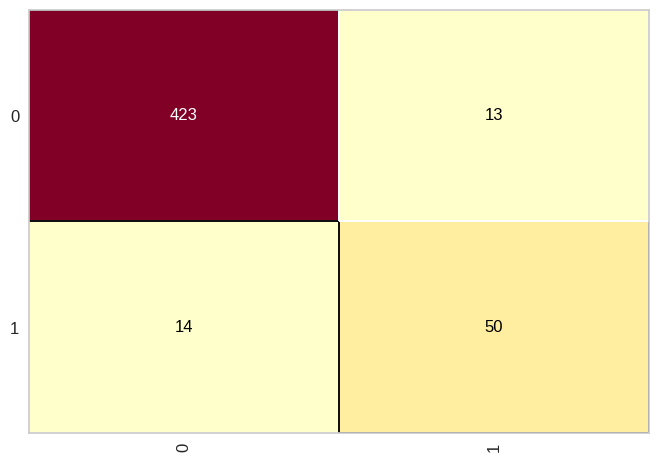

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusão
cm = ConfusionMatrix(logistic_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
print(classification_report(y_credit_teste, previsoes)) #metricas

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       436
           1       0.79      0.78      0.79        64

    accuracy                           0.95       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.95      0.95      0.95       500



## Base census - 84.95%

In [ ]:
import pickle
with open('census.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape#treinamento

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape#teste

((4885, 108), (4885,))

In [ ]:
logistic_census = LogisticRegression(random_state = 1)
#criando a regressao logistica
logistic_census.fit(X_census_treinamento, y_census_treinamento)
#para fazer o treinamento (encontrar o b0 e um coeficiente para cada um dos atributos)

LogisticRegression(random_state=1)

In [ ]:
previsoes = logistic_census.predict(X_census_teste)
#previsoes do algoritmo
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
y_census_teste#valores de teste
#para fins de comparação

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report#metricas
accuracy_score(y_census_teste, previsoes)

0.8497441146366428

0.8497441146366428

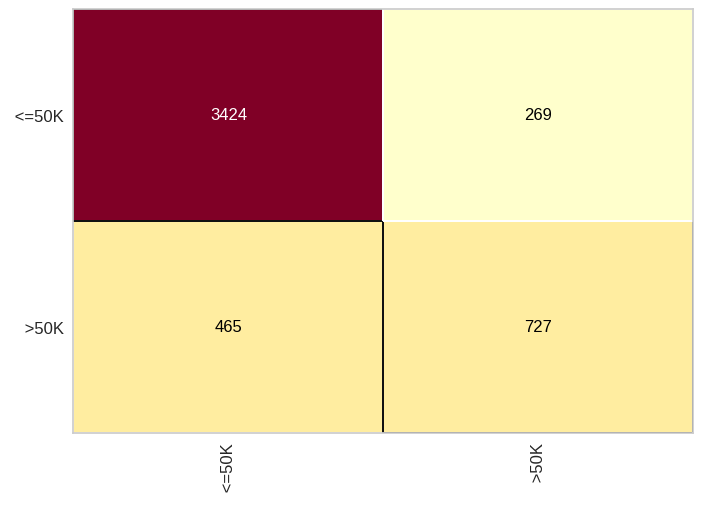

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusão
cm = ConfusionMatrix(logistic_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)

In [ ]:
print(classification_report(y_census_teste, previsoes))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.80      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# SVM

In [ ]:
from sklearn.svm import SVC #svc - nome da classe a ser importada

## Base credit data - 98.80%

In [ ]:
import pickle
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape #registros treinamento

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape #registros de teste

((500, 3), (500,))

In [ ]:
svm_credit = SVC(kernel='rbf', random_state=1, C = 2.0) # 2 -> 4
#kernel='rbf' - tipo do Kernel - base de dados diferentes requerem tipos diferentes de Kernel
#faz o teste e vê o melhor
#random_state=1 - para que sempre que execute tenha o mesmo resultado
#C = 2.0 - maior o valor, mais perfeita a divisão dos dados
svm_credit.fit(X_credit_treinamento, y_credit_treinamento)
#treinamento

SVC(C=2.0, random_state=1)

In [ ]:
previsoes = svm_credit.predict(X_credit_teste)#treinamento
previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
y_credit_teste #respostas reais
#para fins de comparação

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score, classification_report#metricas
accuracy_score(y_credit_teste, previsoes)

0.988

0.988

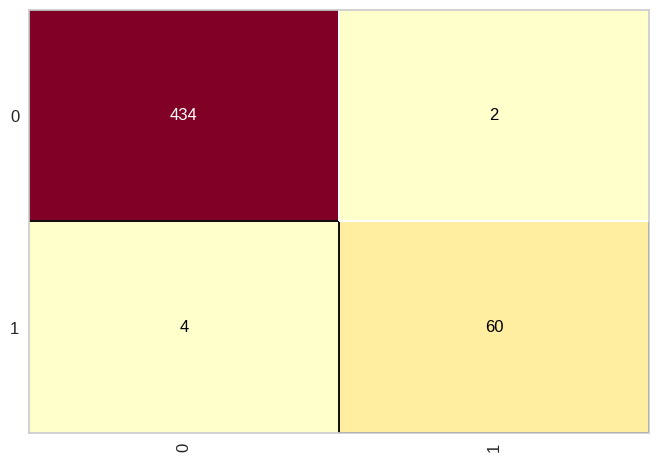

In [ ]:
from yellowbrick.classifier import ConfusionMatrix#matriz de confusão
cm = ConfusionMatrix(svm_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
print(classification_report(y_credit_teste, previsoes))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       436
           1       0.97      0.94      0.95        64

    accuracy                           0.99       500
   macro avg       0.98      0.97      0.97       500
weighted avg       0.99      0.99      0.99       500



## Base census - 85.07%

In [ ]:
import pickle
with open('census.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape #treinamento

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape#teste

((4885, 108), (4885,))

In [ ]:
svm_census = SVC(kernel='linear', random_state=1)
#kernel='linear' - tipo do Kernel - base de dados diferentes requerem tipos diferentes de Kernel
#faz o teste e vê o melhor
#random_state=1 - para que sempre que execute tenha o mesmo resultado
svm_census.fit(X_census_treinamento, y_census_treinamento)

SVC(kernel='linear', random_state=1)

In [ ]:
previsoes = svm_census.predict(X_census_teste)#previsoes
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
y_census_teste#respostas reais
#para fins de comparação

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report#metricas
accuracy_score(y_census_teste, previsoes)

0.8507676560900717

0.8507676560900717

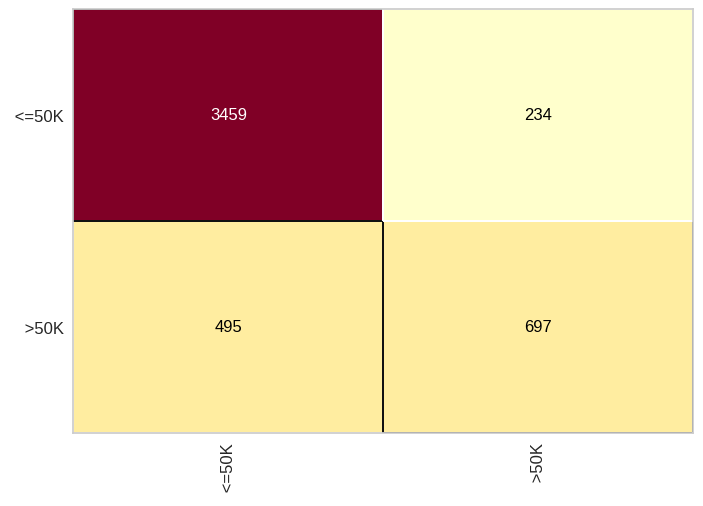

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
#matriz de confusão
cm = ConfusionMatrix(svm_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)

In [ ]:
print(classification_report(y_census_teste, previsoes))#métricas

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      3693
        >50K       0.75      0.58      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.76      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Redes neurais artificiais

In [ ]:
from sklearn.neural_network import MLPClassifier
#MLPClassifier - Multi Layer Perceptron

## Base credit data - 99.80%

In [ ]:
import pickle
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape#treinamento

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape#teste

((500, 3), (500,))

In [ ]:
(3 + 1) / 2

2.0

In [ ]:
# 3 -> 100 -> 100 -> 1
# 3 -> 2 -> 2 -> 1
# o 3 vem do treinamento, 3 atributos e a saída vem da sapida do teste, 0 ou 1 (paga ou nao)
rede_neural_credit = MLPClassifier(max_iter=1500, verbose=True, tol=0.0000100,
                                   #max_iter=1500 - para iteracoes para covergir o erro
                                   #verbose=True - para que o algoritmo mostre as mensagem epoca por epoca
                                   #loss - erro (objetivo é diminuir)
#configurado para ir ate a 1500, mas para na 742, nao precisa ir ate 1500
#Iteration 742, loss = 0.00212129
#Training loss did not improve more than tol=0.000010 for 10 consecutive epochs. Stopping.
#pelo motivo de ele não conseguir melhorar mais o erro, já foi o máximo
#tol=0.0000100 - para que ele possa ir mais, só configurar o parâmetro tol
                                   #sgd, no lugar do adam, é aquele que vai em cada parâmetro atualizando os pesos
                                   solver = 'adam', activation = 'relu',
                                   #activation = 'relu'- para cenarios mais complexos, no lugar do sigmoide
                                   hidden_layer_sizes = (20,20))
                                    #nem sempre uma grande quantidade de neurônios na camada oculta, significa melhor taxa de acerto
#hidden_layer_sizes = (20,20) - duas camadas ocultas e cada uma com 20 neurônios
rede_neural_credit.fit(X_credit_treinamento, y_credit_treinamento)
#faz ajuste dos pesos e encaixa os dados

Iteration 1, loss = 0.92553250
Iteration 2, loss = 0.85819299
Iteration 3, loss = 0.79812767
Iteration 4, loss = 0.74215862
Iteration 5, loss = 0.69036514
Iteration 6, loss = 0.64117412
Iteration 7, loss = 0.59355752
Iteration 8, loss = 0.54764533
Iteration 9, loss = 0.50406826
Iteration 10, loss = 0.46297976
Iteration 11, loss = 0.42584858
Iteration 12, loss = 0.39459797
Iteration 13, loss = 0.36819454
Iteration 14, loss = 0.34460330
Iteration 15, loss = 0.32333017
Iteration 16, loss = 0.30282315
Iteration 17, loss = 0.28273576
Iteration 18, loss = 0.26394634
Iteration 19, loss = 0.24682135
Iteration 20, loss = 0.23225894
Iteration 21, loss = 0.21882052
Iteration 22, loss = 0.20685925
Iteration 23, loss = 0.19582885
Iteration 24, loss = 0.18588136
Iteration 25, loss = 0.17674251
Iteration 26, loss = 0.16869397
Iteration 27, loss = 0.16151112
Iteration 28, loss = 0.15487236
Iteration 29, loss = 0.14891984
Iteration 30, loss = 0.14343173
Iteration 31, loss = 0.13845029
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(20, 20), max_iter=1500, tol=1e-05,
              verbose=True)

In [ ]:
previsoes = rede_neural_credit.predict(X_credit_teste)#previsoes
previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
y_credit_teste#teste
#para fins de comparação

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score, classification_report#metricas
accuracy_score(y_credit_teste, previsoes)

0.998

0.998

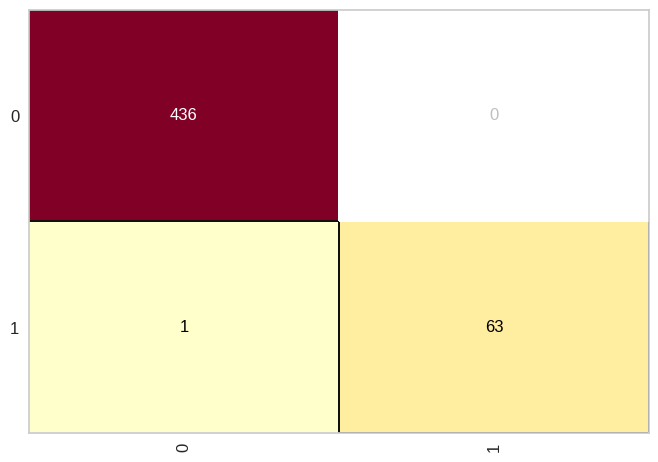

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(rede_neural_credit)#matriz de confusão
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
print(classification_report(y_credit_teste, previsoes))#metricas

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       436
           1       1.00      0.98      0.99        64

    accuracy                           1.00       500
   macro avg       1.00      0.99      1.00       500
weighted avg       1.00      1.00      1.00       500



## Base census - 81.53%

In [ ]:
with open('census.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, y_census_treinamento.shape

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

In [ ]:
(108 + 1) / 2

54.5

In [ ]:
# 108 -> 55 -> 55 -> 1
rede_neural_census = MLPClassifier(verbose=True, max_iter = 1000, tol=0.000010,
                                   #verbose=True - para companhar os valores do erro
                                   #max_iter = 1000 - mil epocas
                                  hidden_layer_sizes = (55,55))
                                  #camadas ocultas
rede_neural_census.fit(X_census_treinamento, y_census_treinamento)

Iteration 1, loss = 0.38801400
Iteration 2, loss = 0.32545809
Iteration 3, loss = 0.31455474
Iteration 4, loss = 0.30818976
Iteration 5, loss = 0.30307398
Iteration 6, loss = 0.29941377
Iteration 7, loss = 0.29617470
Iteration 8, loss = 0.29333482
Iteration 9, loss = 0.29089466
Iteration 10, loss = 0.28874716
Iteration 11, loss = 0.28623589
Iteration 12, loss = 0.28492865
Iteration 13, loss = 0.28184097
Iteration 14, loss = 0.28002334
Iteration 15, loss = 0.27895021
Iteration 16, loss = 0.27747638
Iteration 17, loss = 0.27617808
Iteration 18, loss = 0.27437214
Iteration 19, loss = 0.27271529
Iteration 20, loss = 0.27080927
Iteration 21, loss = 0.26982951
Iteration 22, loss = 0.26766529
Iteration 23, loss = 0.26657398
Iteration 24, loss = 0.26471114
Iteration 25, loss = 0.26290277
Iteration 26, loss = 0.26173137
Iteration 27, loss = 0.26015531
Iteration 28, loss = 0.25889931
Iteration 29, loss = 0.25756264
Iteration 30, loss = 0.25577094
Iteration 31, loss = 0.25464322
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(55, 55), max_iter=1000, tol=1e-05,
              verbose=True)

In [ ]:
previsoes = rede_neural_census.predict(X_census_teste)#previsoes
#os 4k de rsgistros qe vao ser submetidos pra rede neural
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [ ]:
y_census_teste #para comparação

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report#metricas
accuracy_score(y_census_teste, previsoes)
#mais moderno mas nem sempre é o melhor resultado

0.8202661207778915

0.8202661207778915

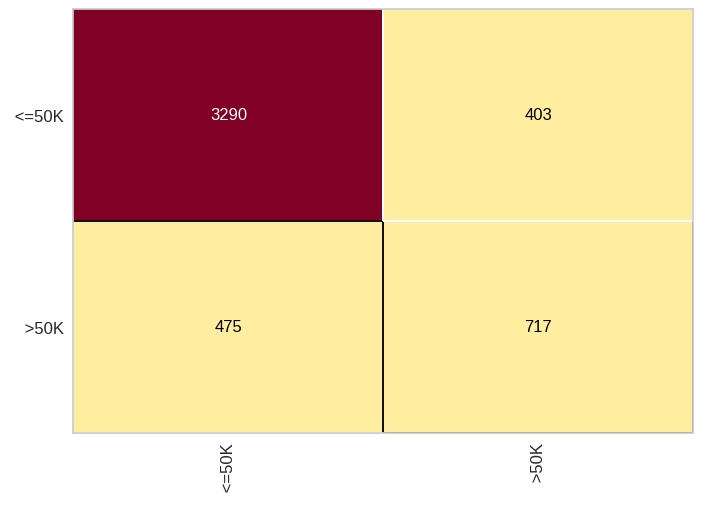

In [ ]:
from yellowbrick.classifier import ConfusionMatrix#matriz de confusão
cm = ConfusionMatrix(rede_neural_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)

In [ ]:
print(classification_report(y_census_teste, previsoes))#metricas

              precision    recall  f1-score   support

       <=50K       0.87      0.89      0.88      3693
        >50K       0.64      0.60      0.62      1192

    accuracy                           0.82      4885
   macro avg       0.76      0.75      0.75      4885
weighted avg       0.82      0.82      0.82      4885



# Avaliação dos algoritmos

- Naïve Bayes: 93.80
- Árvore de decisão: 98.20
- Random forest: 98.40
- Regras: 97.40
- Knn: 98.60
- Regressão logística: 94.60
- SVM: 98.80
- Redes neurais: 99.60

## Tuning dos parâmetros com GridSearch - para achar a melhor validação de cada um dos algoritmos

### Preparação dos dados

In [ ]:
from sklearn.model_selection import GridSearchCV
#GridSearchCV - escolhe os melhores parâmetros, CV - cross validation (validação cruzada)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
#importação dos classificadores
#regras não teve resultados relevantes

In [ ]:
import pickle
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape

((1500, 3), (1500,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape #não precisa essa repartição
#pois na validação cruzada, o próprio algoritmo faz o processo das quebras e validações cruzadas

((500, 3), (500,))

In [ ]:
X_credit = np.concatenate((X_credit_treinamento, X_credit_teste), axis = 0)
#concatenando as duas variáveis
#axis = 0 - concatenando as linhas (1 - colunas)
X_credit.shape

(2000, 3)

In [ ]:
X_credit#renda - idade - dívida

array([[-1.3754462 ,  0.50631087,  0.10980934],
       [ 1.45826409, -1.6489393 , -1.21501497],
       [-0.79356829,  0.22531191, -0.43370226],
       ...,
       [ 1.37445674, -1.05746281, -1.12564819],
       [-1.57087737, -0.63488173, -0.36981671],
       [-1.03572293, -0.93978122,  0.04244312]])

In [ ]:
y_credit = np.concatenate((y_credit_treinamento, y_credit_teste), axis = 0)
#concatenando as respostas esperadas
y_credit.shape

(2000,)

In [ ]:
y_credit#0 - paga e 1 - não paga

array([0, 0, 0, ..., 0, 1, 1])

### Árvore de decisão

In [ ]:
#GridSearch - para achar a melhor validação
parametros = {'criterion': ['gini', 'entropy'],
              #gini e entropia
              'splitter': ['best', 'random'],
              #splitter - estratégia usada para a divisão em cada um dos nós
              'min_samples_split': [2, 5, 10],
              #minimo para quebras na arvore de decisao
              'min_samples_leaf': [1, 5, 10]}
              #minimo registros requeridos para ser considerado um nó folha

In [ ]:
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=parametros)
#estimator=DecisionTreeClassifier() - algoritmo que vão fazer os testes
#param_grid=parametros gridsearch combina todos com todos
grid_search.fit(X_credit, y_credit)
#passando as respostas esperadas
#x - previsores
melhores_parametros = grid_search.best_params_
#alocando os melhores parametros
melhor_resultado = grid_search.best_score_
#alocando os melhores resultados
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
0.983


### Random forest

In [ ]:
#funcionalidade a mesma que o árvore de decisão
parametros = {'criterion': ['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              #numero de estimadores
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [ ]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros)
#estimator=RandomForestClassifier() - algoritmo que vão fazer os testes
#param_grid=parametros gridsearch combina todos com todos
grid_search.fit(X_credit, y_credit)
#passando as respostas esperadas
#x - previsores
melhores_parametros = grid_search.best_params_
#alocando os melhores parametros
melhor_resultado = grid_search.best_score_
#alocando os melhores resultados
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
0.9870000000000001


### Knn

In [ ]:
parametros = {'n_neighbors': [3, 5, 10, 20],#numero de vizinhos
              'p': [1, 2]} #quantidade do k a serem considerados
              #o default é 2

In [ ]:
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
#estimator=KNeighborsClassifier() - algoritmo que vão fazer os testes
#param_grid=parametros gridsearch combina todos com todos
grid_search.fit(X_credit, y_credit)
#passando as respostas esperadas
#x - previsores
melhores_parametros = grid_search.best_params_
#alocando os melhores parametros
melhor_resultado = grid_search.best_score_
#alocando os melhores resultados
print(melhores_parametros)
print(melhor_resultado)

{'n_neighbors': 20, 'p': 1}
0.9800000000000001


### Regressão logística

In [ ]:
parametros = {'tol': [0.0001, 0.00001, 0.000001],#tolerancia
              'C': [1.0, 1.5, 2.0],#maior o valor, mais o algoritmo se encaixa nos dados
              'solver': ['lbfgs', 'sag', 'saga']}#algoritmo usado para encontrar os coeficientes

In [ ]:
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros)
#estimator=LogisticRegression() - algoritmo que vão fazer os testes
#param_grid=parametros gridsearch combina todos com todos
grid_search.fit(X_credit, y_credit)
#passando as respostas esperadas
#x - previsores
melhores_parametros = grid_search.best_params_
#alocando os melhores parametros
melhor_resultado = grid_search.best_score_
#alocando os melhores resultados
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.0001}
0.9484999999999999


### SVM

In [ ]:
parametros = {'tol': [0.001, 0.0001, 0.00001],#tolerancia
              'C': [1.0, 1.5, 2.0],#maior o valor, mais o algoritmo se encaixa nos dados
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}#qual a melhor funcao

In [ ]:
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros)
#estimator=SVC() - algoritmo que vão fazer os testes
#param_grid=parametros gridsearch combina todos com todos
grid_search.fit(X_credit, y_credit)
#passando as respostas esperadas
#x - previsores
melhores_parametros = grid_search.best_params_
#alocando os melhores parametros
melhor_resultado = grid_search.best_score_
#alocando os melhores resultados
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.5, 'kernel': 'rbf', 'tol': 0.001}
0.9829999999999999


### Redes neurais

In [ ]:
parametros = {'activation': ['relu', 'logistic', 'tahn'],
              'solver': ['adam', 'sgd'],
              'batch_size': [10, 56]}

In [ ]:
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros)
#estimator=MLPClassifier( - algoritmo que vão fazer os testes
#param_grid=parametros gridsearch combina todos com todos
grid_search.fit(X_credit, y_credit)
#passando as respostas esperadas
#x - previsores
melhores_parametros = grid_search.best_params_
#alocando os melhores parametros
melhor_resultado = grid_search.best_score_
#alocando os melhores resultados

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [ ]:
print(melhores_parametros)
print(melhor_resultado)

{'activation': 'relu', 'batch_size': 10, 'solver': 'adam'}
0.9964999999999999


## Validação cruzada

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
#cross_val_score - validacao cruzada
#KFold- Técnica mais comumente utilizada para avaliação de algoritmos

In [ ]:
10 * 30

300

In [ ]:
resultados_arvore = []
resultados_random_forest = []
resultados_knn = []
resultados_logistica = []
resultados_svm = []
resultados_rede_neural = []

for i in range(30):#rodando 30 testes - bom pra saber se um algoritmo é melhor que o outro
#cada vez, tem 10 resultados (testes)
  print(i)
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  #n_splits=10 - numero de divisoes na base de dados
  #testando cada uma para teste e as demais pra treinamento
  #shuffle=True - para que o algoritmo sempre misture esses dados
  #random_state=i - cada rodada, passa um random state diferente

  #todos os resultados são a média de 10 execuções

  arvore = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, splitter='best')
  #algoritmo de arvore de decisao e parametros que foram indicados os melhores
  scores = cross_val_score(arvore, X_credit, y_credit, cv = kfold)
  #kfold - para dividir a base de dados
  #cv - recebe os dados divididos e faz todos os testes
  #print(scores) #pra ver os testes
  #print(scores.mean())
  resultados_arvore.append(scores.mean())

  random_forest = RandomForestClassifier(criterion = 'entropy', min_samples_leaf = 1, min_samples_split=5, n_estimators = 10)
  #algoritmo e parametros que foram indicados os melhores
  scores = cross_val_score(random_forest, X_credit, y_credit, cv = kfold)
  #kfold - para dividir a base de dados
  #cv - recebe os dados divididos e faz todos os testes
  resultados_random_forest.append(scores.mean())

  knn = KNeighborsClassifier()
  #algoritmo e parametros (padrões nesse caso) que foram indicados os melhores
  scores = cross_val_score(knn, X_credit, y_credit, cv = kfold)
  #kfold - para dividir a base de dados
  #cv - recebe os dados divididos e faz todos os teste
  resultados_knn.append(scores.mean())

  logistica = LogisticRegression(C = 1.0, solver = 'lbfgs', tol = 0.0001)
  #algoritmo e parametros que foram indicados os melhores
  scores = cross_val_score(logistica, X_credit, y_credit, cv = kfold)
  #kfold - para dividir a base de dados
  #cv - recebe os dados divididos e faz todos os teste
  resultados_logistica.append(scores.mean())

  svm = SVC(kernel = 'rbf', C = 2.0)
  #algoritmo e parametros que foram indicados os melhores
  scores = cross_val_score(svm, X_credit, y_credit, cv = kfold)
  #kfold - para dividir a base de dados
  #cv - recebe os dados divididos e faz todos os teste
  resultados_svm.append(scores.mean())

  rede_neural = MLPClassifier(activation = 'relu', batch_size = 56, solver = 'adam')
  #algoritmo e parametros que foram indicados os melhores
  scores = cross_val_score(rede_neural, X_credit, y_credit, cv = kfold)
  #kfold - para dividir a base de dados
  #cv - recebe os dados divididos e faz todos os teste
  resultados_rede_neural.append(scores.mean())


0


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

1


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

2


...

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

28


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

29


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [ ]:
resultados = pd.DataFrame({'Arvore': resultados_arvore, 'Random forest': resultados_random_forest,
                           'KNN': resultados_knn, 'Logistica': resultados_logistica,
                           'SVM': resultados_svm, 'Rede neural': resultados_rede_neural})
#colocando em dataframe, no formato de dicionário, os resultados obtidos
resultados
#nesse caso, o trabalho tá sendo realizado com base no accuracy, mas pode fazer e implementar com base no precision e o recall

,Arvore,Random forest,KNN,Logistica,SVM,Rede neural
0,0.9865,0.9805,0.9815,0.9475,0.9845,0.9975
1,0.9845,0.9815,0.9800,0.9465,0.9840,0.9970
2,0.9905,0.9880,0.9795,0.9470,0.9865,0.9980
3,0.9880,0.9825,0.9780,0.9460,0.9850,0.9970
4,0.9880,0.9850,0.9820,0.9465,0.9850,0.9980
5,0.9885,0.9830,0.9780,0.9465,0.9845,0.9970
6,0.9885,0.9860,0.9805,0.9470,0.9860,0.9970
7,0.9875,0.9840,0.9800,0.9480,0.9850,0.9970
8,0.9855,0.9850,0.9795,0.9465,0.9840,0.9970
9,0.9870,0.9845,0.9820,0.9465,0.9845,0.9975


In [ ]:
resultados.describe()#estatistica dos resultados
#std - desvio padrao
#muito usado em averiguações de bolsas de valores, ou seja, dp muito alto, pode ter muitas subidas e muitas descidas
#menor std - mais consistente
#comparando no min e no max

,Arvore,Random forest,KNN,Logistica,SVM,Rede neural
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.987250,0.983967,0.980050,0.947000,0.985083,0.997183
std,0.001685,0.002646,0.001533,0.000743,0.001280,0.000382
min,0.984000,0.979500,0.977000,0.945500,0.982000,0.996500
25%,0.986500,0.982125,0.979000,0.946500,0.984125,0.997000
50%,0.987250,0.984000,0.980000,0.947000,0.985000,0.997000
75%,0.988375,0.986000,0.981000,0.947500,0.986375,0.997500
max,0.990500,0.988000,0.982500,0.948500,0.987500,0.998000


In [ ]:
resultados.var() #variancia (recomendado só o desvio padrao)

,0
Arvore,2.840517e-06
Random forest,6.998851e-06
KNN,2.350862e-06
Logistica,5.517241e-07
SVM,1.639368e-06
Rede neural,1.462644e-07


In [ ]:
(resultados.std() / resultados.mean()) * 100#coeficiente de variação em formato de probabilidade

,0
Arvore,0.170715
Random forest,0.268864
KNN,0.156446
Logistica,0.078435
SVM,0.129977
Rede neural,0.038353


## Teste de normalidade nos resultados

- Shapiro: https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test

In [ ]:
#intuito de responder se um algoritmo é melhor que o outro
alpha = 0.05 #confiança do teste em 95% (valor padrao de teste de hipotese)

In [ ]:
from scipy.stats import shapiro #shapiro é uma fórmula matemática - vai dizer se a função é ou não normal

In [ ]:
#aplicando os resultados na formula
shapiro(resultados_arvore), shapiro(resultados_random_forest), shapiro(resultados_knn), shapiro(resultados_logistica), shapiro(resultados_svm), shapiro(resultados_rede_neural)
#se os valores de P (o valor desses resultados) = Alpha

(ShapiroResult(statistic=np.float64(0.971280602795241), pvalue=np.float64(0.5747806912386675)),
 ShapiroResult(statistic=np.float64(0.9539037518887856), pvalue=np.float64(0.21482280561684103)),
 ShapiroResult(statistic=np.float64(0.9584024823930501), pvalue=np.float64(0.2818135378764127)),
 ShapiroResult(statistic=np.float64(0.9309147727892649), pvalue=np.float64(0.05193074013090626)),
 ShapiroResult(statistic=np.float64(0.9622985607506823), pvalue=np.float64(0.3541579284945434)),
 ShapiroResult(statistic=np.float64(0.8525897035593092), pvalue=np.float64(0.0007028176219676914)))

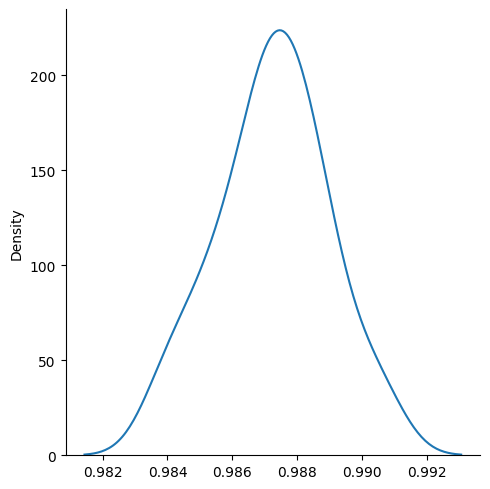

In [ ]:
#analisando se todos se encaixam na distribuição normal
sns.displot(resultados_arvore, kind = 'kde');#resultados da arvore de decisao
#kind = 'kde' - traça a linha do histograma

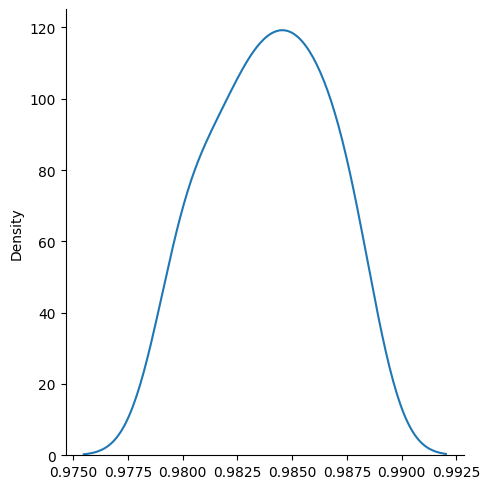

In [ ]:
sns.displot(resultados_random_forest, kind = 'kde');#resultados da random forest
#kind = 'kde' - traça a linha do histograma

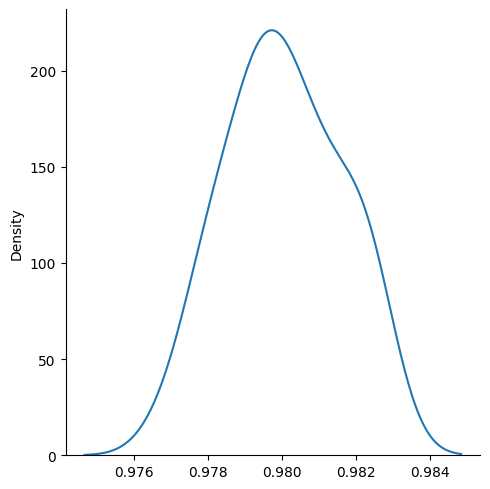

In [ ]:
sns.displot(resultados_knn, kind = 'kde');#resultados do knn
#kind = 'kde' - traça a linha do histograma

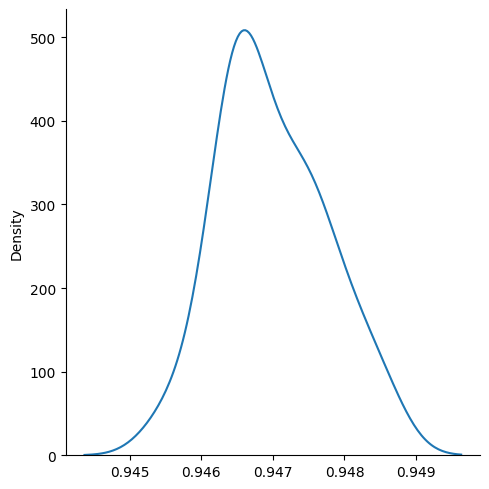

In [ ]:
sns.displot(resultados_logistica, kind = 'kde');#resultados da regressao logistica
#kind = 'kde' - traça a linha do histograma

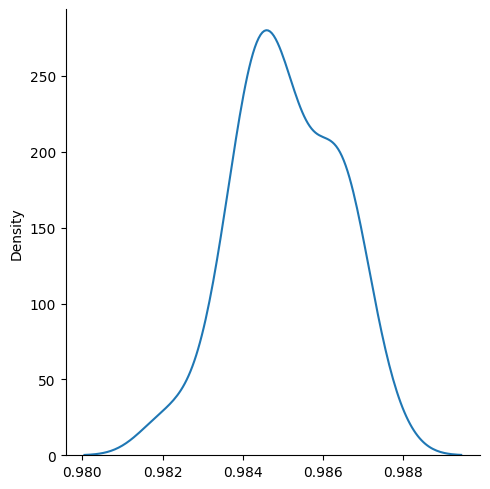

In [ ]:
sns.displot(resultados_svm, kind = 'kde');#resultados do svm
#kind = 'kde' - traça a linha do histograma

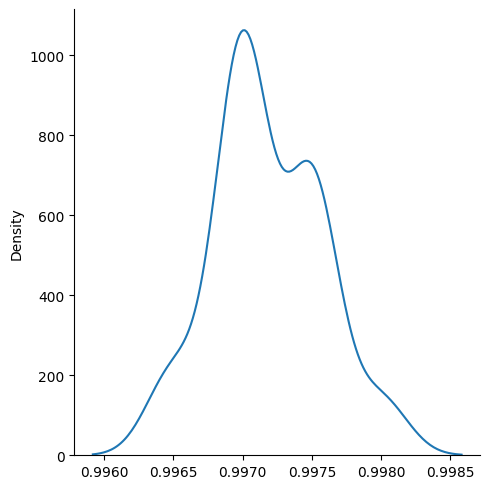

In [ ]:
sns.displot(resultados_rede_neural, kind = 'kde');#resultados das redes neurais
#kind = 'kde' - traça a linha do histograma

## Teste de hipótese com ANOVA e Tukey

In [ ]:
#anova e tukey são para dados que estão em uma distribuição normal
#rede neural nao ta, mas grande parte dele esta semelhante a distribuicao normal
from scipy.stats import f_oneway #funcao para o teste

In [ ]:
p = f_oneway(resultados_arvore, resultados_random_forest, resultados_knn, resultados_logistica, resultados_svm, resultados_rede_neural)
#se nao tivesse, ficaria mais complicado_
p

F_onewayResult(statistic=np.float64(3663.439512619736), pvalue=np.float64(3.095059865536445e-174))

In [ ]:
#verificando a distancia estatistica
alpha = 0.05
if p.pvalue <= alpha:
  print('Hipótese nula rejeitada. Dados são diferentes')
else:
  print('Hipótese alternativa rejeitada. Resultados são iguais')

Hipótese nula rejeitada. Dados são diferentes


In [ ]:
#vendo o resultado e qual o melhor
#concatenando todos os resultados
#sabendo que tem 30 resultados pra cada, então coloca 30x os nomes
resultados_algoritmos = {'accuracy': np.concatenate([resultados_arvore, resultados_random_forest, resultados_knn, resultados_logistica, resultados_svm, resultados_rede_neural]),
                         'algoritmo': ['arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore',
                          'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
                          'knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn',
                          'logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica',
                          'svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm',
                          'rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural','rede_neural']}

In [ ]:
resultados_df = pd.DataFrame(resultados_algoritmos)#estrutura para aplicar o teste estatistico
resultados_df

,accuracy,algoritmo
0,0.9865,arvore
1,0.9845,arvore
2,0.9905,arvore
3,0.9880,arvore
4,0.9880,arvore
...,...,...
175,0.9975,rede_neural
176,0.9975,rede_neural
177,0.9970,rede_neural
178,0.9975,rede_neural


In [ ]:
from statsmodels.stats.multicomp import MultiComparison
#.multicomp comparacao multipla entre os resultados

In [ ]:
compara_algoritmos = MultiComparison(resultados_df['accuracy'], resultados_df['algoritmo'])
#comparando as colunas accuracy e algoritmo

In [ ]:
teste_estatistico = compara_algoritmos.tukeyhsd()
#.tukeyhsd() teste estatistico para comparar todos os grupos
print(teste_estatistico)
#true em todos eles - ha diferença estatistica entre eles

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
       arvore           knn  -0.0072    0.0 -0.0084  -0.006   True
       arvore     logistica  -0.0402    0.0 -0.0414 -0.0391   True
       arvore random_forest  -0.0033    0.0 -0.0044 -0.0021   True
       arvore   rede_neural   0.0099    0.0  0.0088  0.0111   True
       arvore           svm  -0.0022    0.0 -0.0033  -0.001   True
          knn     logistica   -0.033    0.0 -0.0342 -0.0319   True
          knn random_forest   0.0039    0.0  0.0028  0.0051   True
          knn   rede_neural   0.0171    0.0   0.016  0.0183   True
          knn           svm    0.005    0.0  0.0039  0.0062   True
    logistica random_forest    0.037    0.0  0.0358  0.0381   True
    logistica   rede_neural   0.0502    0.0   0.049  0.0513   True
    logistica           svm   0.0381    0.0  0.0369  0.0392   

In [ ]:
resultados.mean() #o algoritmo de rede neural é estatisticamente superior ao de arvore (segundo lugar)

,0
Arvore,0.987250
Random forest,0.983967
KNN,0.980050
Logistica,0.947000
SVM,0.985083
Rede neural,0.997183


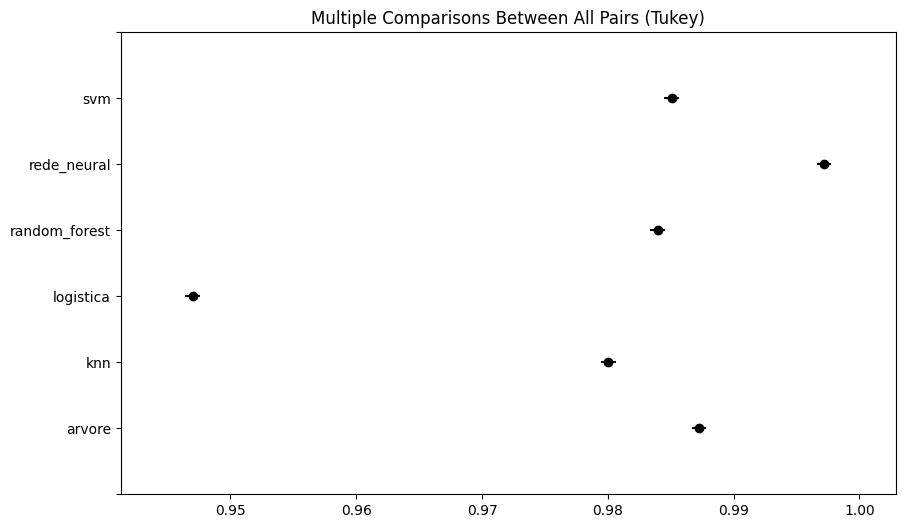

In [ ]:
teste_estatistico.plot_simultaneous(); #grafico de teste estatistico
#grafico interessante para artigo cientifico

# Salvar um classificador já treinado

In [ ]:
#fazer somente depois de ter feito a avaliação de todo o algoritmo
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
#unindo a base de dados
X_credit = np.concatenate((X_credit_treinamento, X_credit_teste), axis = 0)
y_credit = np.concatenate((y_credit_treinamento, y_credit_teste), axis = 0)

In [ ]:
X_credit.shape, y_credit.shape

((2000, 3), (2000,))

In [ ]:
#selecionando os algoritmos que vao ser usados
#3 melhores
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [ ]:
#classificador de rede neural e os parametros
classificador_rede_neural = MLPClassifier(activation='relu', batch_size = 56, solver='adam')
classificador_rede_neural.fit(X_credit, y_credit)#treinamento e geração
#como quer gerar o modelo final, pode passar a base de dados completa para utilizar numa base de dados comercial

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=56)

In [ ]:
classificador_arvore = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, splitter='best')
classificador_arvore.fit(X_credit, y_credit)#treinamento e geração
#como quer gerar o modelo final, pode passar a base de dados completa para utilizar numa base de dados comercial

DecisionTreeClassifier(criterion='entropy', min_samples_split=5)

In [ ]:
classificador_svm = SVC(C = 2.0, kernel='rbf', probability=True)
classificador_svm.fit(X_credit, y_credit)#treinamento e geração
#como quer gerar o modelo final, pode passar a base de dados completa para utilizar numa base de dados comercial

SVC(C=2.0, probability=True)

In [ ]:
#salvando os classificadores em disco
#.sav - extensao utilizada pelo sklearning
import pickle
pickle.dump(classificador_rede_neural, open('rede_neural_finalizado.sav', 'wb'))
pickle.dump(classificador_arvore, open('arvore_finalizado.sav', 'wb'))
pickle.dump(classificador_svm, open('svm_finalizado.sav', 'wb'))

# Carregar um classificador já treinado

In [ ]:
#carregando os classificadores salvos - como seria feito se fosse feita uma api
rede_neural = pickle.load(open('rede_neural_finalizado.sav', 'rb'))
arvore = pickle.load(open('arvore_finalizado.sav', 'rb'))
svm = pickle.load(open('svm_finalizado.sav', 'rb'))

In [ ]:
novo_registro = X_credit[1999]
novo_registro
#valor nao estao na escala normal pois foram padronizados

array([-1.03572293, -0.93978122,  0.04244312])

In [ ]:
novo_registro.shape#em formato de vetor

(3,)

In [ ]:
novo_registro = novo_registro.reshape(1, -1) #reshape para formato de matriz
novo_registro.shape

(1, 3)

In [ ]:
novo_registro

array([[-1.03572293, -0.93978122,  0.04244312]])

In [ ]:
rede_neural.predict(novo_registro)#passando um novo registro
#vai sair a resposta do algoritmo (se paga (1) ou não paga (0))

array([1])

In [ ]:
arvore.predict(novo_registro)#passando um novo registro
#vai sair a resposta do algoritmo (se paga (1) ou não paga (0))

array([1])

In [ ]:
svm.predict(novo_registro)#passando um novo registro
#vai sair a resposta do algoritmo (se paga (1) ou não paga (0))

array([1])

# Combinação de classificadores

In [ ]:
novo_registro = X_credit[1999]
novo_registro = novo_registro.reshape(1, -1)#colocando em formato de matrix
novo_registro, novo_registro.shape

(array([[-1.03572293, -0.93978122,  0.04244312]]), (1, 3))

In [ ]:
#carregando a resposta dos três
resposta_rede_neural = rede_neural.predict(novo_registro)
resposta_arvore = arvore.predict(novo_registro)
resposta_svm = svm.predict(novo_registro)

In [ ]:
resposta_rede_neural[0], resposta_arvore[0], resposta_svm[0] #vendo as respostas

(np.int64(1), np.int64(1), np.int64(1))

In [ ]:
#vendo quantos classificadores geram resposta da classe 1
#e quantos classificadores geram resposta da classe 0
paga = 0
nao_paga = 0

if resposta_rede_neural[0] == 1:
  nao_paga += 1
else:
  paga += 1

if resposta_arvore[0] == 1:
  nao_paga += 1
else:
  paga += 1

if resposta_svm[0] == 1:
  nao_paga += 1
else:
  paga += 1

if paga > nao_paga:
  print('Cliente pagará o empréstimo')
elif paga == nao_paga:
  print('Empate') #bom usar numero impar pra evitar empate
  #ou fazer aloritmo para peso de cada um deles
else:
  print('Cliente não pagará o empréstimo')

Cliente não pagará o empréstimo


# Rejeição de classificadores

In [ ]:
novo_registro = X_credit[1999]
novo_registro = novo_registro.reshape(1, -1)
novo_registro, novo_registro.shape
#dados padronizados do cliente
#Renda, idade e dívida

(array([[-1.03572293, -0.93978122,  0.04244312]]), (1, 3))

In [ ]:
resposta_rede_neural = rede_neural.predict(novo_registro)
resposta_arvore = arvore.predict(novo_registro)
resposta_svm = svm.predict(novo_registro)

In [ ]:
resposta_rede_neural[0], resposta_arvore[0], resposta_svm[0]
#predict retornando só a classe

(np.int64(1), np.int64(1), np.int64(1))

In [ ]:
probabilidade_rede_neural = rede_neural.predict_proba(novo_registro)
#_proba do sklearning que gera o valor da probabilidade
probabilidade_rede_neural

array([[8.62628849e-05, 9.99913737e-01]])

In [ ]:
confianca_rede_neural = probabilidade_rede_neural.max()#probabilidade máxima
confianca_rede_neural
#confiabilidade da probabilidade

np.float64(0.9999137371151259)

In [ ]:
probabilidade_arvore = arvore.predict_proba(novo_registro)
#_proba do sklearning que gera o valor da probabilidade
confianca_arvore = probabilidade_arvore.max()#probabilidade máxima
confianca_arvore
#confiabilidade da probabilidade

np.float64(1.0)

In [ ]:
probabilidade_svm = svm.predict_proba(novo_registro)
#_proba do sklearning que gera o valor da probabilidade
confianca_svm = probabilidade_svm.max()#probabilidade máxima
confianca_svm
#confiabilidade da probabilidade

np.float64(0.9900736442016653)

In [ ]:
#vendo quantos classificadores geram resposta da classe 1
#e quantos classificadores geram resposta da classe 0
#verificando a confiança do algoritmo
#contando quantos algoritmos foram utilizados
paga = 0
nao_paga = 0
confianca_minima = 0.999999
#0.999999 confiança mínima
algoritmos = 0

if confianca_rede_neural >= confianca_minima:
  algoritmos += 1
  if resposta_rede_neural[0] == 1:
    nao_paga += 1
  else:
    paga += 1

if confianca_arvore >= confianca_minima:
  algoritmos += 1
  if resposta_arvore[0] == 1:
    nao_paga += 1
  else:
    paga += 1

if confianca_svm >= confianca_minima:
  algoritmos += 1
  if resposta_svm[0] == 1:
    nao_paga += 1
  else:
    paga += 1

if paga > nao_paga:
  print('Cliente pagará o empréstimo, baseado em {} algoritmos'.format(algoritmos))
  #.format(algoritmos) - passando o valor da variável algoritmos para dentro da chave
elif paga == nao_paga:
  print('Empate, baseado em {} algoritmos'.format(algoritmos))
  #.format(algoritmos) - passando o valor da variável algoritmos para dentro da chave
else:
  print('Cliente não pagará o empréstimo, baseado em {} algoritmos'.format(algoritmos))
  #.format(algoritmos) - passando o valor da variável algoritmos para dentro da chave

Cliente não pagará o empréstimo, baseado em 1 algoritmos


# Redução de dimensionalidade

## Preparacão da base de dados

In [ ]:
base_census = pd.read_csv('/content/census.csv')
base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
X_census = base_census.iloc[:, 0:14].values
X_census

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      dtype=object)

In [ ]:
y_census = base_census.iloc[:, 14].values
y_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

In [ ]:
X_census[:,1] = label_encoder_workclass.fit_transform(X_census[:,1])
X_census[:,3] = label_encoder_education.fit_transform(X_census[:,3])
X_census[:,5] = label_encoder_marital.fit_transform(X_census[:,5])
X_census[:,6] = label_encoder_occupation.fit_transform(X_census[:,6])
X_census[:,7] = label_encoder_relationship.fit_transform(X_census[:,7])
X_census[:,8] = label_encoder_race.fit_transform(X_census[:,8])
X_census[:,9] = label_encoder_sex.fit_transform(X_census[:,9])
X_census[:,13] = label_encoder_country.fit_transform(X_census[:,13])

In [ ]:
X_census[0]

array([39, 7, 77516, 9, 13, 4, 1, 1, 4, 1, 2174, 0, 40, 39], dtype=object)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_census = StandardScaler()
X_census = scaler_census.fit_transform(X_census)

In [ ]:
X_census

array([[ 0.03067056,  2.15057856, -1.06361075, ..., -0.21665953,
        -0.03542945,  0.29156857],
       [ 0.83710898,  1.46373585, -1.008707  , ..., -0.21665953,
        -2.22215312,  0.29156857],
       [-0.04264203,  0.09005041,  0.2450785 , ..., -0.21665953,
        -0.03542945,  0.29156857],
       ...,
       [ 1.42360965,  0.09005041, -0.35877741, ..., -0.21665953,
        -0.03542945,  0.29156857],
       [-1.21564337,  0.09005041,  0.11095988, ..., -0.21665953,
        -1.65522476,  0.29156857],
       [ 0.98373415,  0.77689313,  0.92989258, ..., -0.21665953,
        -0.03542945,  0.29156857]])

In [ ]:
from sklearn.model_selection import train_test_split
X_census_treinamento, X_census_teste, y_census_treinamento, y_census_teste = train_test_split(X_census, y_census, test_size=0.15, random_state=0)

In [ ]:
X_census_treinamento.shape, X_census_teste.shape

((27676, 14), (4885, 14))

## PCA (Principal component analysis)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=8)

In [ ]:
X_census_treinamento_pca = pca.fit_transform(X_census_treinamento)
X_census_testes_pca = pca.transform(X_census_teste)

In [ ]:
X_census_treinamento_pca.shape, X_census_testes_pca.shape

((27676, 8), (4885, 8))

In [ ]:
X_census_treinamento

array([[-0.92239303,  1.46373585,  1.84273483, ..., -0.21665953,
        -0.03542945,  0.29156857],
       [-0.84908045,  0.09005041,  0.19630465, ..., -0.21665953,
         3.20416118,  0.29156857],
       [ 1.42360965, -1.28363502,  2.83572992, ..., -0.21665953,
        -0.03542945,  0.29156857],
       ...,
       [-1.14233079,  0.09005041, -1.36867471, ..., -0.21665953,
        -0.03542945,  0.29156857],
       [ 0.47054606, -1.28363502,  0.24712496, ..., -0.21665953,
         0.36951938,  0.29156857],
       [-0.99570562,  0.09005041, -0.02703374, ..., -0.21665953,
         0.61248868,  0.29156857]])

In [ ]:
pca.explained_variance_ratio_

array([0.151561  , 0.10109701, 0.08980379, 0.08076277, 0.07627678,
       0.07357646, 0.06772289, 0.06690789])

In [ ]:
pca.explained_variance_ratio_.sum()

0.7077085943199357

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest_census_pca = RandomForestClassifier(n_estimators=40, random_state=0, criterion = 'entropy')
random_forest_census_pca.fit(X_census_treinamento_pca, y_census_treinamento)

RandomForestClassifier(criterion='entropy', n_estimators=40, random_state=0)

In [ ]:
previsoes = random_forest_census_pca.predict(X_census_testes_pca)
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_census_teste, previsoes)

0.8372569089048106

## Kernel PCA

In [ ]:
from sklearn.decomposition import KernelPCA

In [ ]:
kpca = KernelPCA(n_components=8, kernel='rbf')
X_census_treinamento_kpca = kpca.fit_transform(X_census_treinamento)
X_census_teste_kpca = kpca.transform(X_census_teste)

In [ ]:
X_census_treinamento_kpca.shape, X_census_teste_kpca.shape

In [ ]:
X_census_treinamento_kpca

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest_census_kpca = RandomForestClassifier(n_estimators = 40, criterion = 'entropy', random_state = 0)
random_forest_census_kpca.fit(X_census_treinamento_kpca, y_census_treinamento)

In [ ]:
previsoes = random_forest_census_kpca.predict(X_census_teste_kpca)
previsoes

In [ ]:
y_census_teste

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_census_teste, previsoes)

## LDA (Linear discriminant analysis)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components = 8)

In [ ]:
X_census_treinamento_lda = lda.fit_transform(X_census_treinamento, y_census_treinamento)
X_census_teste_lda = lda.transform(X_census_teste)

In [ ]:
X_census_treinamento_lda.shape, X_census_teste_lda.shape

In [ ]:
X_census_treinamento_lda

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest_census_lda = RandomForestClassifier(n_estimators = 40, criterion = 'entropy', random_state = 0)
random_forest_census_lda.fit(X_census_treinamento_lda, y_census_treinamento)

In [ ]:
previsoes = random_forest_census_lda.predict(X_census_teste_lda)
previsoes

In [ ]:
y_census_teste

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_census_teste, previsoes)

# Detecção de outliers

## Boxplot

In [ ]:
base_credit = pd.read_csv('credit_data.csv')
base_credit

In [ ]:
base_credit.isnull().sum()

In [ ]:
base_credit.dropna(inplace=True)

In [ ]:
base_credit.isnull().sum()

In [ ]:
1997 / 2

In [ ]:
# Outliers idade
grafico = px.box(base_credit, y = 'age')
grafico.show()

In [ ]:
outliers_age = base_credit[base_credit['age'] < 0]
outliers_age

In [ ]:
# Outliers loan
grafico = px.box(base_credit, y='loan')
grafico.show()

In [ ]:
outliers_loan = base_credit[base_credit['loan'] > 13300]
outliers_loan

## Gráfico de dispersão

In [ ]:
# Income x age
grafico = px.scatter(x = base_credit['income'], y = base_credit['age'])
grafico.show()

In [ ]:
# Income x loan
grafico = px.scatter(x = base_credit['income'], y = base_credit['loan'])
grafico.show()

In [ ]:
# Age x loan
grafico = px.scatter(x = base_credit['age'], y = base_credit['loan'])
grafico.show()

In [ ]:
base_census = pd.read_csv('census.csv')
base_census

In [ ]:
# Age x final weight
grafico = px.scatter(x = base_census['age'], y = base_census['final-weight'])
grafico.show()

## Biblioteca PyOD

- Documentação: https://pyod.readthedocs.io/en/latest/#

In [ ]:
!pip install pyod

In [ ]:
from pyod.models.knn import KNN

In [ ]:
base_credit.head(1)

In [ ]:
detector = KNN()
detector.fit(base_credit.iloc[:,1:4])

In [ ]:
previsoes = detector.labels_
previsoes

In [ ]:
np.unique(previsoes, return_counts=True)

In [ ]:
confianca_previsoes = detector.decision_scores_
confianca_previsoes

In [ ]:
outliers = []
for i in range(len(previsoes)):
  #print(i)
  if previsoes[i] == 1:
    outliers.append(i)

In [ ]:
print(outliers)

In [ ]:
lista_outliers = base_credit.iloc[outliers,:]
lista_outliers